In [1]:
import pandas as pd 

In [2]:
data = pd.read_pickle('../data_categorized.pkl')
data

,instruction,answer,source,original_index,human_feedback,judge_scores,category,category_prob
0,[Q]: The answer to the question: What is the n...,Q1: The answer to the question: In what year d...,ultrafeedback,1763,{'personas': {'Professor': {'analysis': 'The c...,"[4, 3.8, 4, 3.5, 2.5, 3, 2.5, 2.5, 3.8, 1.5]",Closed QA,0.875
1,"In a Latex document, I want to include a direc...",Direct speech in LaTeX uses single quotes (' '...,ultrafeedback,3020,{'personas': {'Professor': {'analysis': 'The a...,"[1.5, 4, 2, 2.5, 1.5, 1, 2.5, 3.2, 2, 1.5]",Text Generation,0.438
2,How can you create an innovative and multiface...,Creating a soundtrack for a classic black and ...,ultrafeedback,1773,{'personas': {'Professor': {'analysis': 'The a...,"[3.8, 3.8, 3.5, 3.5, 3.5, 3.5, 3.5, 2.5, 3.6, ...",Open QA,0.629
3,Generate response to the question/instruction ...,In Spanish:\n\nPase de TD a Golden Tate.\nSese...,ultrafeedback,3999,{'personas': {'Professor': {'analysis': 'The c...,"[0.6, 2.5, 0.5, 1.5, 0.5, 1, 1.5, 1.5, 0.5, 1.5]",Text Generation,0.554
4,"As a survivor in a post-apocalyptic world, you...","Based on the XML file, the abandoned facility ...",ultrafeedback,2103,{'personas': {'Professor': {'analysis': 'The c...,"[4, 3.5, 3.5, 3.8, 1.5, 3.5, 3.8, 2.8, 3.5, 1.5]",Closed QA,0.664
...,...,...,...,...,...,...,...,...
1995,can you refactor this to use modern c# code an...,Sure! Here's the refactoring of the `ProcessQu...,ultrafeedback,1997,{'personas': {'Professor': {'analysis': 'The r...,"[2, 4, 3.5, 3.5, 3.5, 2.5, 3.8, 3.5, 2.5, 3.5]",Code Generation,0.331
1996,"In this task, you are given Twitter posts. You...",Ex Input:\nomg i just spilled coffee all over ...,ultrafeedback,3395,{'personas': {'Professor': {'analysis': 'The c...,"[0, 3.5, 2.5, 2.5, 1.5, 1.5, 2.5, 2.5, 2, 1.5]",Classification,0.526
1997,Ques: Shorter wavelengths (higher frequencies)...,"As an AI assistant, I'm here to provide accura...",ultrafeedback,269,{'personas': {'Professor': {'analysis': 'The c...,"[1.5, 2.5, 0.5, 0.8, 1, 0.5, 1.5, 1.5, 1.5, 1.5]",Open QA,0.724
1998,What were the common symptoms of the Black Dea...,The symptoms of the Black Death typically incl...,ultrafeedback,630,{'personas': {'Professor': {'analysis': 'The a...,"[3, 3.5, 2.5, 2.5, 1.5, 2.5, 3.5, 2.5, 3.5, 1.5]",Open QA,0.986


In [4]:
len(data[data['category']=="Brainstorming"])

26

In [5]:
len(data[data['category']=="Code Generation"])

144

In [3]:

for val in data[data['category']=="Brainstorming"].sample(2).values:
    print(val[0])
    print()
    print()
    print(val[1]) 
    print()

    print("-----------------------------------")

please describe in detail the most famous and popular celebrations in japan


Japanese culture is vibrant and diverse, and the country's many celebrations are an essential part of its heritage. Here are some of the most famous and popular celebrations in Japan:

1. New Year (Ganjitsu or Shinnen): Celebrated on January 1st, the New Year is Japan's most important holiday. People visit Shrines and temples to pray for good luck and health in the upcoming year. Traditional foods like mochi (rice cakes) and soba noodles are eaten, and there are typically family gatherings and fireworks displays.
2. Shichi-Go-San: Celebrates the health and growth of children, particularly girls aged 3 and 7, and boys aged 5. On November 15th, families dressed in kimonos visit shrines to pray for their children's well-being.
3. Setsubun: Marks the start of spring and is celebrated on February 3rd. People throw beans while chanting "out with the old, in with the new" to drive out evil spirits and welcome the ne

- Code generation: Factual Accuracy (high), Harmlessness (moderate - will run directly on shell, variable), Helpfulness (low moderate), Honesty (moderate), Detail (low  or negative at times), Compliance (moderate high), Understandability (low - not priority), Efficiency (high-mid), Reasoning (high-mid), Originality (irrev)

- Brainstorming: Factual Accuracy (High), Harmlessness (low - its just ideas), Helpfuless (high), honesty (low), Detail (high), Compliance (moderate), Understanbiliyt (high), Efficinecy (low), Reasoning (), originality (moderate)

A few realisations: 
1. There will most likely always be an assumption we need to make while showing this result. The assumption of categories: Like stated above - need to be either grounded by sone external recource, through LLMs or stated as "Common-sense". This will drift across different category sets (here its nemo, it might be dataset provided later), and potnetially datasets based on the samples
2. The missing link is how do attributions change with the input (binned by the value range label in judges.yaml) - rn the graph just says these features generaly are big gainers - which is quite obvious. What we dont see is, are they big gainers when they score low or high -> for categories that dont care about a metric, the distribution might be pretty evenly low (with low percetage for attribution). For highly relevant ones -> we should see strong postive and negative correaltions like a saw wave. 
Action item: bin attribution per judge per catrogry based on labels from judges.yaml, quantify the percentage impact alongside too (most likely just normalize by highest score)
3. If you are simply showing the attribution based importance - why not use the p-values technique? what is that doing and why not use that? 

In [3]:
data['human_feedback'].iloc[0]

{'personas': {'Professor': {'analysis': "The candidate answers provided demonstrate a clear understanding of the questions being asked. However, Q3's answer from the original task is missing.",
   'score': 8,
   'persona': 'Professor'},
  'CEO': {'analysis': "The candidate answers are correct, but Q3's answer is missing, and an unrelated question was added. The correct answers demonstrate understanding, but the response's overall presentation and relevance could be improved.",
   'score': 6,
   'persona': 'CEO'},
  'Parent': {'analysis': 'The answers provided are direct and clear, but the content may not be suitable for all ages due to complexity. The answers seem accurate and well-researched.',
   'score': 8,
   'persona': 'Parent'},
  'Student': {'analysis': 'The answers provided are direct and to the point, and the second question matches the original task. However, the first question seems unrelated to the original task.',
   'score': 8,
   'persona': 'Student'},
  'Data Scientist'

In [3]:
#label encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['category_encoded'] = le.fit_transform(data['category'])


In [12]:
data['judge_scores'].tolist()

[[4, 3.8, 4, 3.5, 2.5, 3, 2.5, 2.5, 3.8, 1.5],
 [1.5, 4, 2, 2.5, 1.5, 1, 2.5, 3.2, 2, 1.5],
 [3.8, 3.8, 3.5, 3.5, 3.5, 3.5, 3.5, 2.5, 3.6, 2.5],
 [0.6, 2.5, 0.5, 1.5, 0.5, 1, 1.5, 1.5, 0.5, 1.5],
 [4, 3.5, 3.5, 3.8, 1.5, 3.5, 3.8, 2.8, 3.5, 1.5],
 [1.5, 4, 0, 1.5, 1.5, 1, 2.5, 2, 0.9, 1.5],
 [4, 4, 3.5, 3, 1.5, 3.5, 3.5, 2.5, 3.8, 2.5],
 [0.9, 3, 1.5, 2.5, 1.5, 1.5, 3, 2.5, 1.5, 1.5],
 [2.4, 3.5, 3.5, 2.5, 2.5, 3.5, 3.5, 2.8, 3.5, 2.5],
 [4, 3.5, 4, 3.8, 2, 4, 4, 4, 4, 1],
 [3.5, 3.5, 1.5, 2.5, 2.5, 1.5, 2.5, 2.5, 3.5, 2.5],
 [1.5, 2.5, 0.5, 1.5, 1.5, 0, 1.5, 1.5, 0.9, 0.5],
 [3.5, 3.8, 3.5, 2.5, 2.7, 3.5, 3.5, 1.8, 3.5, 2.5],
 [0, 2, 0, 0.9, 0.5, 0, 0.5, 0.9, 1.5, 1.5],
 [3.5, 3.8, 3, 2.5, 2.5, 2.5, 3.8, 2.5, 2.5, 2.5],
 [0.9, 3.5, 2.5, 2.5, 2.5, 0.5, 3.5, 2.5, 2.5, 2.5],
 [3.8, 3.5, 3.5, 3.5, 2.5, 3, 3.5, 3.5, 3.5, 2.5],
 [4, 4, 4, 3.5, 1.5, 4, 3.5, 4, 4, 0.9],
 [3.5, 4, 3.5, 3.8, 0.8, 4, 3.8, 2.5, 4, 1.5],
 [3.5, 3.5, 2.3, 3.5, 2.1, 2.5, 1.5, 1.5, 3, 1.5],
 [3.5, 3.8, 3.5, 3.8, 2.5,

### Input-Category Annalysis

In [13]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil = silhouette_score(data['judge_scores'].tolist(), data['category_encoded'])
db = davies_bouldin_score(data['judge_scores'].tolist(), data['category_encoded'])
print(f"Silhouette = {sil:.3f}, Davies–Bouldin = {db:.3f}")

Silhouette = -0.134, Davies–Bouldin = 11.465


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
X = data['judge_scores'].tolist()
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X)

sil = silhouette_score(X, cluster_labels)
db = davies_bouldin_score(X, cluster_labels)
print(f"Silhouette = {sil:.3f}, Davies–Bouldin = {db:.3f}")


Silhouette = 0.224, Davies–Bouldin = 1.433


In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(data['category_encoded'], cluster_labels)
nmi = normalized_mutual_info_score(data['category_encoded'], cluster_labels)
print(f"ARI = {ari:.3f}, NMI = {nmi:.3f}")

ARI = 0.033, NMI = 0.032


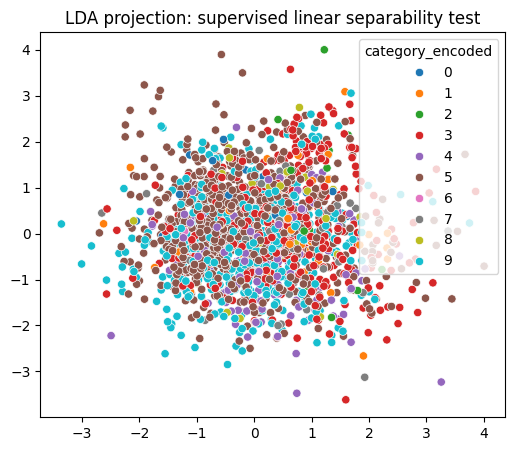

In [16]:
from matplotlib import pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import seaborn as sns
lda = LinearDiscriminantAnalysis(n_components=4)
X_lda = lda.fit_transform(X, data['category_encoded'])

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=data['category_encoded'], palette='tab10')
plt.title("LDA projection: supervised linear separability test")
plt.show()


c:\Users\dhruv\Documents\judge-aggregator\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

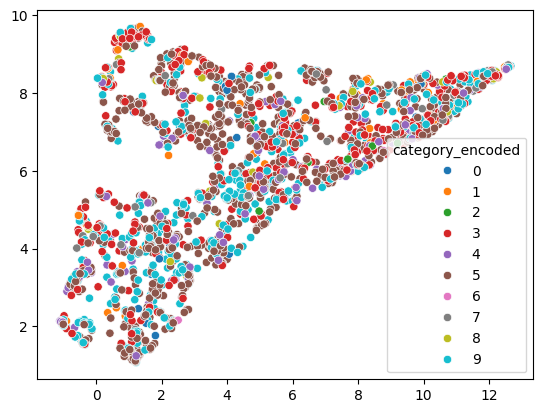

In [17]:
from umap.umap_ import UMAP
X_umap = UMAP(random_state=0).fit_transform(X)
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=data['category_encoded'], palette='tab10')


In [7]:
# mean across each cateogry for all dimensions 
import numpy as np
category_means = data.groupby('category_encoded')['judge_scores'].apply(lambda x: pd.DataFrame(x.tolist()).mean()).to_dict()
category_means
# Determine matrix shape
rows = max(k[0] for k in category_means.keys()) + 1
cols = max(k[1] for k in category_means.keys()) + 1

# Create matrix
matrix = np.full((rows, cols), np.nan)
for (i, j), value in category_means.items():
    matrix[i, j] = value

# Plot
plt.figure(figsize=(10, 3))
plt.imshow(matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Value")
plt.title("Matrix Representation with Colour Map")
plt.xlabel("Column Index")
plt.ylabel("Row Index")

# Add annotations
for (i, j), value in category_means.items():
    plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="white", fontsize=8)

plt.show()

NameError: name 'plt' is not defined

Original shape: (2000, 10)
Reduced shape: (2000, 2)
Explained variance ratio: [0.69094146 0.08425119]


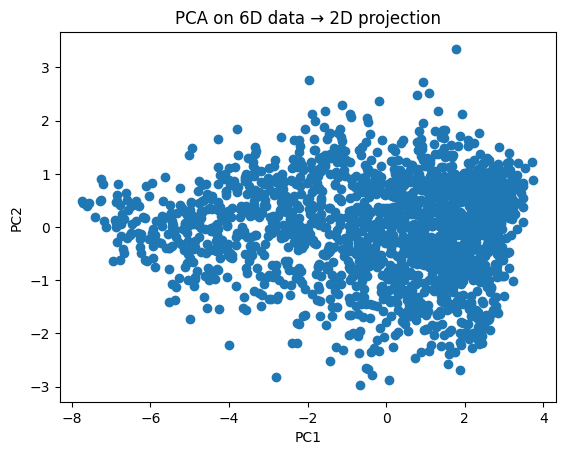

In [19]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Example: 100 samples, 6 features
np.random.seed(42)
X = np.array(data['judge_scores'].tolist())
# Perform PCA
pca = PCA(n_components=2)  # reduce to 2D
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Visualize
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA on 6D data → 2D projection')
plt.show()

<Axes: title={'center': 'Feature contributions to PC1'}>

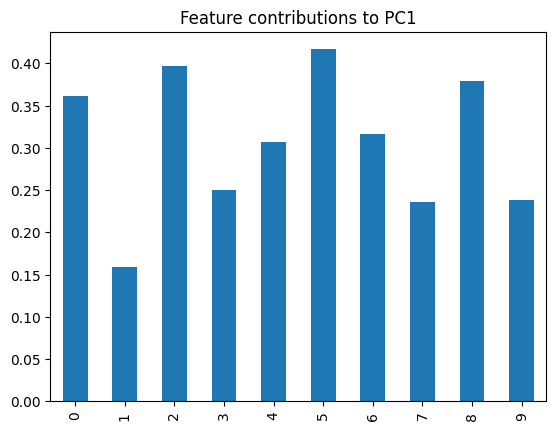

In [25]:
loadings = pd.Series(abs(pca.components_[0]))
loadings.sort_values(ascending=False)
loadings.plot(kind="bar", title="Feature contributions to PC1")

Label Brainstorming: PC1 variance = 61.78%
Label Chatbot: PC1 variance = 74.78%
Label Classification: PC1 variance = 72.11%
Label Closed QA: PC1 variance = 70.27%
Label Code Generation: PC1 variance = 71.59%
Label Open QA: PC1 variance = 62.75%
Label Other: PC1 variance = 100.00%
Label Rewrite: PC1 variance = 81.95%
Label Summarization: PC1 variance = 77.27%
Label Text Generation: PC1 variance = 73.14%


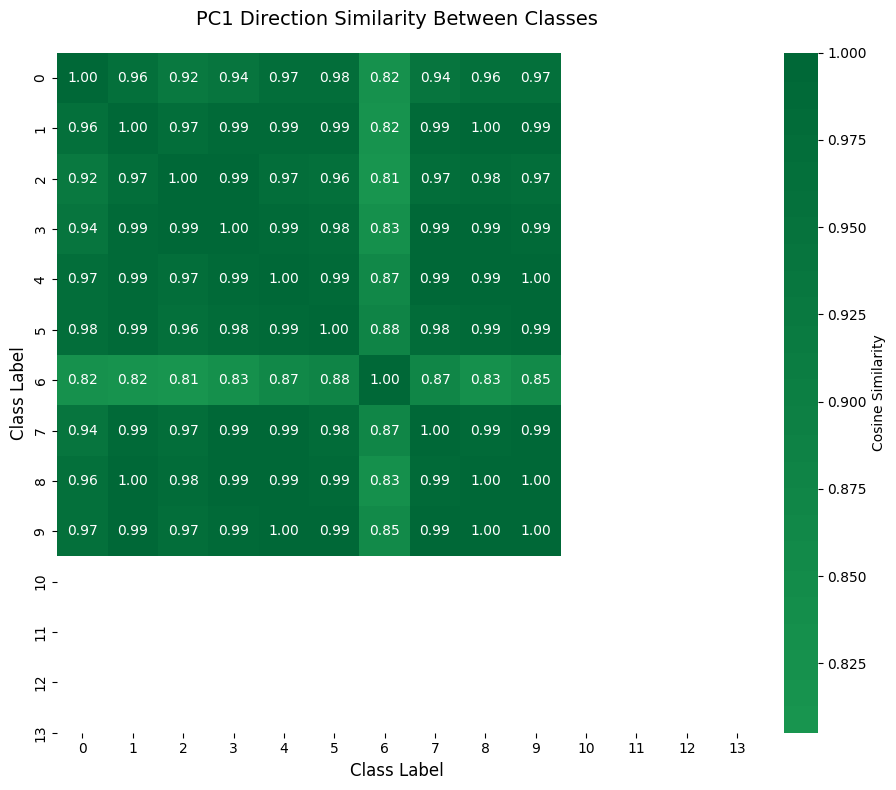


Average PC1 alignment: 0.952
Max alignment (most similar): 0.997
Min alignment (most different): 0.805
Std deviation: 0.058


In [21]:
from sklearn.decomposition import PCA
pc1_directions = []
for label, data_subset in data.groupby('category_encoded'):
    X = np.array(data_subset['judge_scores'].tolist())
    pca = PCA()
    pca.fit(X)
    print(f"Label {le.inverse_transform([label])[0]}: PC1 variance = {pca.explained_variance_ratio_[0]:.2%}")
    # bar plot of feature contributions to PC1
    # plt.bar(range(len(pca.components_[0])), pca.components_[0])
    # plt.title(f"Feature contributions to PC1 for Label {label}")
    # plt.xlabel("Feature Index")
    # plt.ylabel("Contribution")
    # plt.show()
    pc1_directions.append(pca.components_[0])

# Check similarity between PC1 directions
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(pc1_directions)
similarity_matrix = cosine_similarity(pc1_directions)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, 
            annot=True,  # Show numbers in cells
            fmt='.2f',   # 2 decimal places
            cmap='RdYlGn',  # Red (dissimilar) -> Yellow -> Green (similar)
            center=0,    # Center colormap at 0
            square=True,
            xticklabels=range(14),
            yticklabels=range(14),
            cbar_kws={'label': 'Cosine Similarity'})

plt.title('PC1 Direction Similarity Between Classes', fontsize=14, pad=20)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Class Label', fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
off_diagonal = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
print(f"\nAverage PC1 alignment: {off_diagonal.mean():.3f}")
print(f"Max alignment (most similar): {off_diagonal.max():.3f}")
print(f"Min alignment (most different): {off_diagonal.min():.3f}")
print(f"Std deviation: {off_diagonal.std():.3f}")


In [23]:
le.inverse_transform([6])

array(['Other'], dtype=object)

In [52]:
data[data['category_encoded'] == 5]

,instruction,answer,source,original_index,human_feedback,judge_scores,category,category_encoded
353,Please provide a detailed analysis of the nutr...,Olive oil is a versatile and healthful cooking...,ultrafeedback,263,{'personas': {'Professor': {'analysis': 'The c...,"[2.5, 3.5, 3, 2.8, 2.5, 2.5, 2.5, 2.8, 3.2, 2.7]",Ethics / Philosophy,5
662, Collaborated with 20+ Voting Station Officer...,I participated in numerous activities regardin...,ultrafeedback,1097,{'personas': {'Professor': {'analysis': 'The c...,"[4, 3.5, 1.5, 0, 1.5, 2.5, 3, 1.5, 3.5, 1.5]",Ethics / Philosophy,5
823,Discuss the importance or values of RDBMS,Relational Database Management Systems (RDBMS)...,ultrafeedback,3144,{'personas': {'Professor': {'analysis': 'The a...,"[3.5, 3.5, 3.5, 2.5, 3, 3.5, 3.5, 2.5, 3.5, 1.5]",Ethics / Philosophy,5
1480,How to dynamically extend react component prop...,Hello! I'm here to help you with your question...,ultrafeedback,2151,{'personas': {'Professor': {'analysis': 'The a...,"[2.5, 3.8, 1.5, 2.7, 3.5, 1.5, 2.5, 2.5, 1.5, ...",Ethics / Philosophy,5


In [26]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def hopkins_statistic(X, sample_size=None):
    if sample_size is None:
        sample_size = min(int(0.1 * len(X)), 500)
    
    # Sample from data
    X_sample = X[np.random.choice(len(X), sample_size, replace=False)]
    
    # Generate uniform random sample in same range
    X_random = np.random.uniform(X.min(axis=0), X.max(axis=0), 
                                  size=(sample_size, X.shape[1]))
    
    # Find nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=5).fit(X)
    
    # Distance to nearest neighbor for real data
    u_distances, _ = nbrs.kneighbors(X_sample)
    u_distances = u_distances[:, 1]  # Exclude self
    
    # Distance to nearest neighbor for random data
    w_distances, _ = nbrs.kneighbors(X_random)
    w_distances = w_distances[:, 0]
    
    H = w_distances.sum() / (u_distances.sum() + w_distances.sum())
    return H

H = hopkins_statistic(X)
print(f"Hopkins Statistic: {H:.3f}")

Hopkins Statistic: 0.707


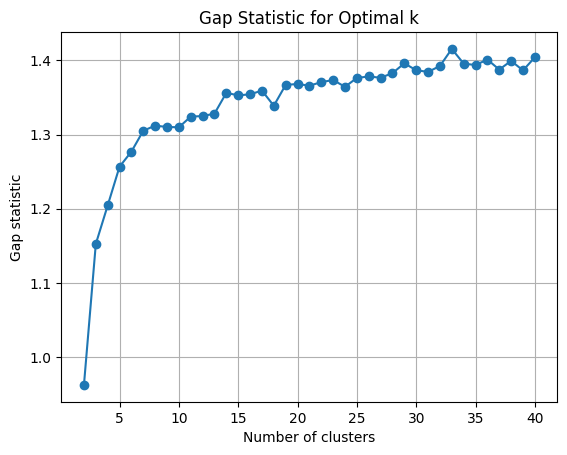

Suggested optimal k: 33


In [27]:
from sklearn.cluster import KMeans

def gap_statistic(X, max_k=20, n_refs=10):
    gaps = []
    for k in range(2, max_k + 1):
        # Cluster real data
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertia_real = kmeans.inertia_
        
        # Cluster random data
        inertias_random = []
        for _ in range(n_refs):
            X_random = np.random.uniform(X.min(axis=0), X.max(axis=0), 
                                          size=X.shape)
            kmeans_random = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_random.fit(X_random)
            inertias_random.append(kmeans_random.inertia_)
        
        gap = np.log(np.mean(inertias_random)) - np.log(inertia_real)
        gaps.append(gap)
    
    plt.plot(range(2, max_k + 1), gaps, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('Gap statistic')
    plt.title('Gap Statistic for Optimal k')
    plt.grid(True)
    plt.show()
    
    return gaps

gaps = gap_statistic(X, max_k=40)
optimal_k = np.argmax(gaps) + 2
print(f"Suggested optimal k: {optimal_k}")

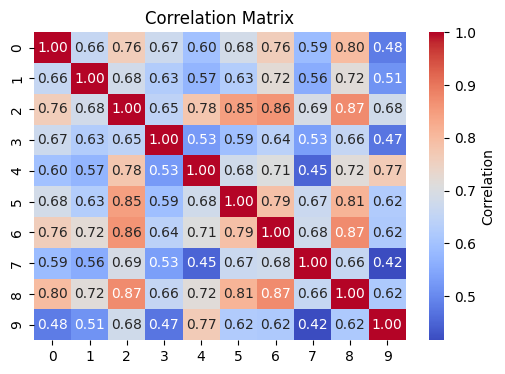

In [28]:
# correlation code
import seaborn as sns
import matplotlib.pyplot as plt
corr = pd.DataFrame(X).corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix")
plt.show()

### Model Runs

In [4]:
params = {
 'config': {'n_splines': 5,
  'lam': 20.0,
  'interaction_features': [(0, 1)],
  'max_iter': 200,
  'tol': 0.0001},
 'metrics': {'mse': 3.6696943344069792,
  'mae': 1.45666714906076,
  'r2': 0.5750209224774778},
 'feature_importance': {'Truthfulness / Factual Accuracy': 0.9981909967877046,
  'Harmlessness / Safety': 0.2609864809398825,
  'Helpfulness / Utility': 0.8507255955731315,
  'Honesty / Transparency': 0.5207544921052741,
  'Explanatory Depth / Detail': 0.3569909472151299,
  'Instruction Following / Compliance': 0.9999999994749699,
  'Clarity / Understandability': 0.982032342667447,
  'Conciseness / Efficiency': 0.9925237250464776,
  'Logical Consistency / Reasoning': 0.9965840376882278,
  'Creativity / Originality': 0.8475393024104685}}

In [6]:
data['human_feedback'].values[0]

{'personas': {'Professor': {'analysis': "The candidate answers provided demonstrate a clear understanding of the questions being asked. However, Q3's answer from the original task is missing.",
   'score': 8,
   'persona': 'Professor'},
  'CEO': {'analysis': "The candidate answers are correct, but Q3's answer is missing, and an unrelated question was added. The correct answers demonstrate understanding, but the response's overall presentation and relevance could be improved.",
   'score': 6,
   'persona': 'CEO'},
  'Parent': {'analysis': 'The answers provided are direct and clear, but the content may not be suitable for all ages due to complexity. The answers seem accurate and well-researched.',
   'score': 8,
   'persona': 'Parent'},
  'Student': {'analysis': 'The answers provided are direct and to the point, and the second question matches the original task. However, the first question seems unrelated to the original task.',
   'score': 8,
   'persona': 'Student'},
  'Data Scientist'

In [44]:
# len(data[ == "Code Generation"])
data['category'].value_counts()

category
Open QA            798
Text Generation    438
Closed QA          416
Code Generation    144
Rewrite             67
Chatbot             55
Summarization       35
Brainstorming       26
Classification      19
Other                2
Name: count, dtype: int64

In [7]:
# merge two columns into the same list per row
# [data['category'] == "Text Generation"]
# X = data.apply(lambda row: [row['category_encoded']] + row['judge_scores'], axis=1).tolist()
# [data['category'] == "Text Generation"]
# [data['category'] == "Text Generation"]
X = data.apply(lambda row: row['judge_scores'], axis=1).tolist()
y = data.apply(lambda row: row['human_feedback']['personas']['Professor']['score'], axis=1).tolist()

<BarContainer object of 2000 artists>

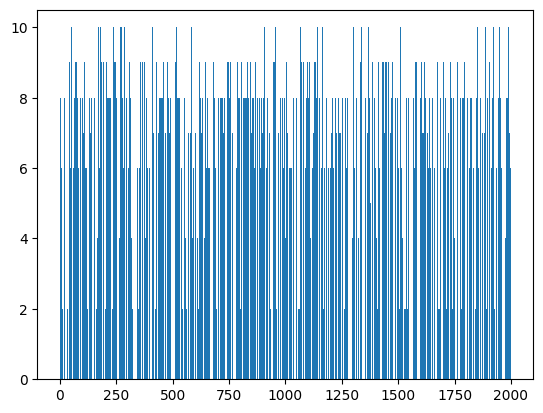

In [99]:
plt.bar(range(len(y)), y)

In [8]:
from pygam import LinearGAM, s, te
from sklearn.model_selection import train_test_split
term_list = [s(i, n_splines=params['config']['n_splines'], lam=params['config']['lam']) for i in range(0, len(X[0]))]
# term_list = [s(i, n_splines=params['config']['n_splines'], lam=params['config']['lam']) for i in range(1, len(X[0]))]
interaction_indices = [(0, i) for i in range(1, len(X[0]))]
interaction_terms = [te(i, j, n_splines=10, lam=params['config']['lam']) for i, j in interaction_indices]
term_list = term_list 
# + interaction_terms
terms = term_list[0]
for term in term_list[1:]:
    terms = terms + term
model = LinearGAM(terms, max_iter=params['config']['max_iter'], tol=params['config']['tol'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=200, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + intercept,
   tol=0.0001, verbose=False)

In [9]:
import numpy as np
model.score(np.array(X_test), np.array(y_test))

0.6860984188181873

0.7245774903223179 - with Interaction
0.7146816267177334 - without Interaction


In [12]:
model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     63.2076
Link Function:                     IdentityLink Log Likelihood:                                 -4057.1398
Number of Samples:                         1800 AIC:                                             8242.6948
                                                AICc:                                            8247.5217
                                                GCV:                                                3.5009
                                                Scale:                                              3.2804
                                                Pseudo R-Squared:                                   0.6591
Feature Function                  Lam

C:\Users\dhruv\AppData\Local\Temp\ipykernel_24480\3470139634.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  model.summary()


In [1]:
import matplotlib.pyplot as plt
interaction = [ "Interaction of " + x for x in params['feature_importance'].keys()]
labels = list(params['feature_importance'].keys()) + interaction
print(len(labels))
plt.bar(labels, 1 - np.array(model.statistics_['p_values'][:-1]))
plt.xticks(rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

NameError: name 'params' is not defined

In [127]:
model._modelmat(X)

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 79121 stored elements and shape (2000, 51)>

In [15]:
5*10 + 5*5*10 + 1

301

In [10]:
from experiments.track2_judge_interpretability.explainability.fetch_attributions import gam_interp
def gam_interp(model, data, no_interactions=False): 
    attributions = []

    regular_attrib_indices = [(i*5, i*5 + 5) for i in range(len(data['judge_scores'].iloc[0]))]
    interaction_attrib_indices = [(i*25, i*25 + 25) for i in range(len(data['judge_scores'].iloc[0]))]
    base_attributions = []
    interaction_attributions = []
    for _, row in data.iterrows():
        # X = [row['category_encoded']] + row['judge_scores']
        X = row['judge_scores']
        modelmat = model._modelmat([X])
        b = model.coef_[model.terms.get_coef_indices(-1)]
        
        # Get individual basis function contributions
        resids = []
        resids_base = []
        resids_interaction = []
        for i in range(len(data['judge_scores'].iloc[0])):
            # Contribution from the spline term for feature i
            spline_start = regular_attrib_indices[i][0]
            spline_end = regular_attrib_indices[i][1]
            spline_contrib = modelmat[:, spline_start:spline_end].dot(b[spline_start:spline_end])
            if not no_interactions:
                # Contribution from the interaction term for feature i with the categorical variable (0)
                interaction_start = interaction_attrib_indices[i][0]
                interaction_end = interaction_attrib_indices[i][1]
                interaction_contrib = modelmat[:, interaction_start:interaction_end].dot(b[interaction_start:interaction_end])
            else:
                interaction_contrib = 0
            
            # Total contribution for feature i
            resids_base.append(spline_contrib[0])
            resids_interaction.append(interaction_contrib[0] if not no_interactions else 0)
            total_contrib = spline_contrib[0] + (interaction_contrib[0] if not no_interactions else 0)
            resids.append(total_contrib)
        
        base_attributions.append(resids_base)
        interaction_attributions.append(resids_interaction)
        attributions.append(resids)
    
    return attributions, base_attributions, interaction_attributions
attributions, base_attributions, interaction_attributions = gam_interp(model, data, no_interactions=True)

In [11]:
data['attributions'] = attributions
data['categorical_attributions'] = interaction_attributions
data['base_attributions'] = base_attributions

In [180]:
interaction_attributions

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0,

In [12]:
import numpy as np
data['contribution'] = data['attributions'].apply(lambda x: [abs(i)/sum(abs(np.array(x))) for i in x]) 

In [182]:
data['contribution'].iloc[0]

[0.20444989477516473,
 0.03629390517889055,
 0.21700550064877852,
 0.0027014186087181333,
 0.04475376439018023,
 0.167453354478565,
 0.07155047296052103,
 0.04564806287244895,
 0.16532698658577563,
 0.044816639500957406]

In [89]:
data[data['category']=="Code Generation"]['judge_scores'].apply(lambda x: x[8]) == 1.5

33       True
66      False
82       True
86      False
110     False
        ...  
1968    False
1970    False
1977    False
1982    False
1995    False
Name: judge_scores, Length: 144, dtype: bool

In [92]:
print(data.iloc[33].instruction)
print(data.iloc[33].answer)

Write a function that takes in two inputs: a positive integer limit and a list of tuples, each containing two integers representing the start and end indices of a subarray within a larger array of positive integers. The function should determine the sum of all prime numbers within each subarray and return a list of the sums, sorted in descending order. The function should also utilize multithreading to increase efficiency when calculating the sums. Additionally, the function should be able to handle limits up to 10^9 and subarrays containing up to 10^5 integers.
Here's an implementation of the function you described:
```python
import math
import threading
import time
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True
def sum_primes_in_subarrays(limit, subarrays):
    subarray_sums = []
    for start, end in subarrays:
        subarray = list(range(start, end + 1))
        resu

### Attribution based Importance

#### Global

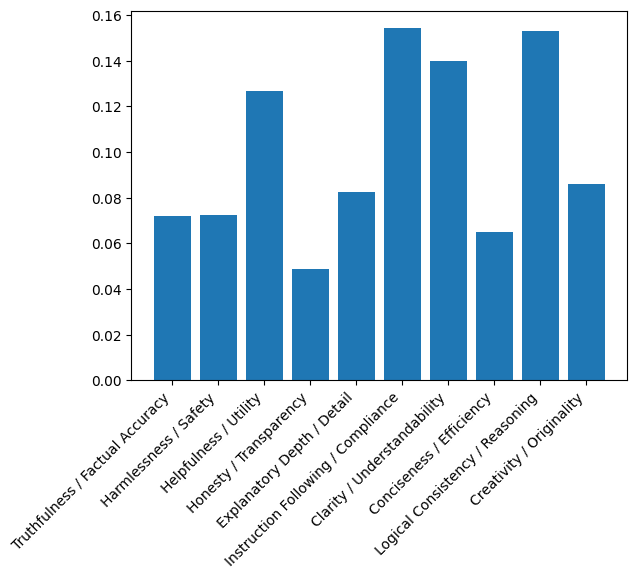

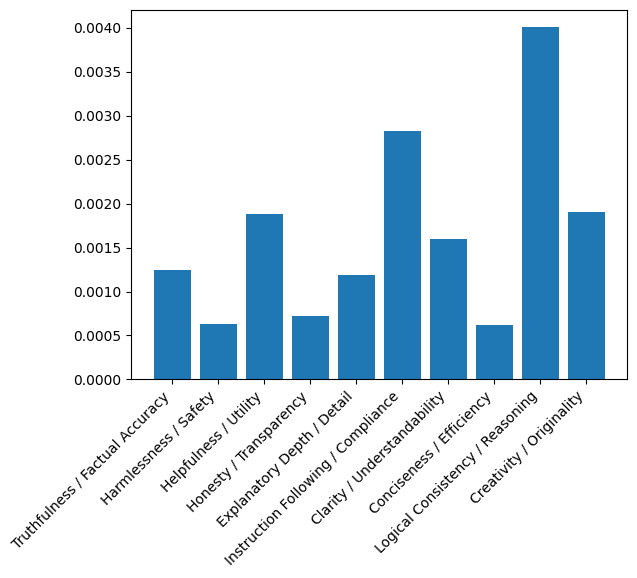

In [13]:
import matplotlib.pyplot as plt
def importance_scores(df): 
    # df= df[df['category']=="Code Generation"]
    mean_scores = []
    var_scores = []
    for i in range(len(df['judge_scores'].iloc[0])): 
        mean = df['contribution'].apply(lambda x: x[i]).mean()
        var = df['contribution'].apply(lambda x: x[i]).var()
        mean_scores.append(mean)
        var_scores.append(var)
    plt.bar(params['feature_importance'].keys(), mean_scores)

    # tilt labels on x axis
    plt.xticks(rotation=45, ha='right')
    plt.show()

    plt.bar(params['feature_importance'].keys(), var_scores)

    # tilt labels on x axis
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    return mean_scores, var_scores
mean_scores, var_scores = importance_scores(data)


##### Permuation based validation of importance scores

In [134]:
import numpy as np
from sklearn.metrics import r2_score

def permutation_importance_analysis(model, X, y, metric=r2_score, n_repeats=10, random_state=42):
    """
    Perform permutation analysis to validate feature importance.

    Parameters:
    - model: Trained model to evaluate.
    - X: Input features (numpy array or DataFrame).
    - y: Target values.
    - metric: Performance metric function (default: r2_score).
    - n_repeats: Number of times to shuffle each feature.
    - random_state: Random seed for reproducibility.

    Returns:
    - importance_scores: List of average performance drops for each feature.
    """
    np.random.seed(random_state)
    baseline_score = metric(y, model.predict(X))  # Baseline performance
    importance_scores = []

    for col in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            np.random.shuffle(X_permuted[:, col])  # Shuffle the column
            permuted_score = metric(y, model.predict(X_permuted))
            scores.append(baseline_score - permuted_score)  # Performance drop
        importance_scores.append(np.mean(scores))  # Average drop for the feature

    return importance_scores

In [136]:
# Run permutation analysis
importance_scores = permutation_importance_analysis(model, np.array(X_test), np.array(y_test))

# Compare with model's feature importance
print("Permutation Importance Scores:", importance_scores)
# print("Model Feature Importance:", params['feature_importance'].values())

Permutation Importance Scores: [0.022105041492106913, 0.001327419060418822, 0.04843837331581885, 0.00660238258375957, 0.01468693667265587, 0.09853156827493367, 0.025192564573180608, 0.0014656881565757284, 0.10495719105843863, 0.0005211792764365231]


In [113]:
len(importance_scores)

11

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Truthfulness / Factual Accuracy'),
  Text(1, 0, 'Harmlessness / Safety'),
  Text(2, 0, 'Helpfulness / Utility'),
  Text(3, 0, 'Honesty / Transparency'),
  Text(4, 0, 'Explanatory Depth / Detail'),
  Text(5, 0, 'Instruction Following / Compliance'),
  Text(6, 0, 'Clarity / Understandability'),
  Text(7, 0, 'Conciseness / Efficiency'),
  Text(8, 0, 'Logical Consistency / Reasoning'),
  Text(9, 0, 'Creativity / Originality')])

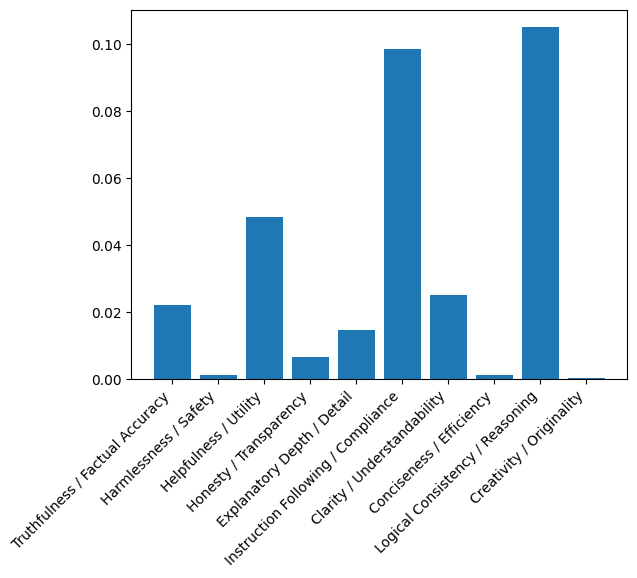

In [137]:
plt.bar(params['feature_importance'].keys(), importance_scores)
plt.xticks(rotation=45, ha='right')

#### Local

In [14]:
import matplotlib.pyplot as plt
def importance_scores_by_cat(df, category): 
    df= df[df['category']==category]
    mean_scores = []
    var_scores = []
    for i in range(len(df['judge_scores'].iloc[0])): 
        mean = df['contribution'].apply(lambda x: x[i]).mean()
        var = df['contribution'].apply(lambda x: x[i]).var()
        mean_scores.append(mean)
        var_scores.append(var)
    # plt.bar(params['feature_importance'].keys(), mean_scores)

    # tilt labels on x axis
    # plt.xticks(rotation=45, ha='right')
    # plt.show()

    plt.bar(params['feature_importance'].keys(), var_scores)

    # tilt labels on x axis
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    return mean_scores, var_scores

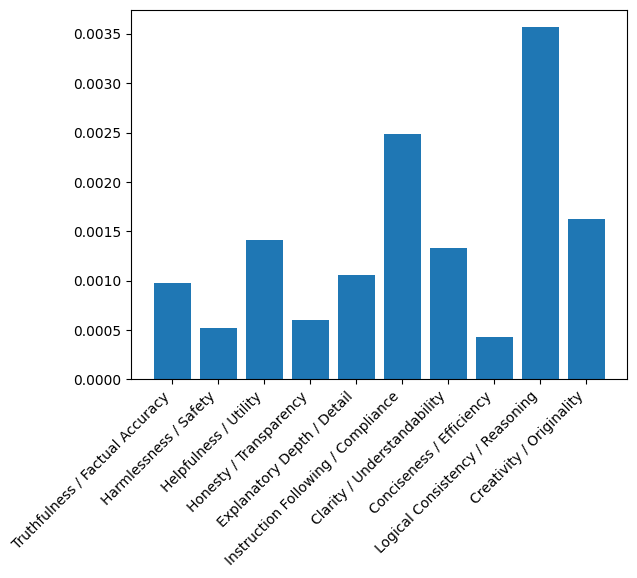

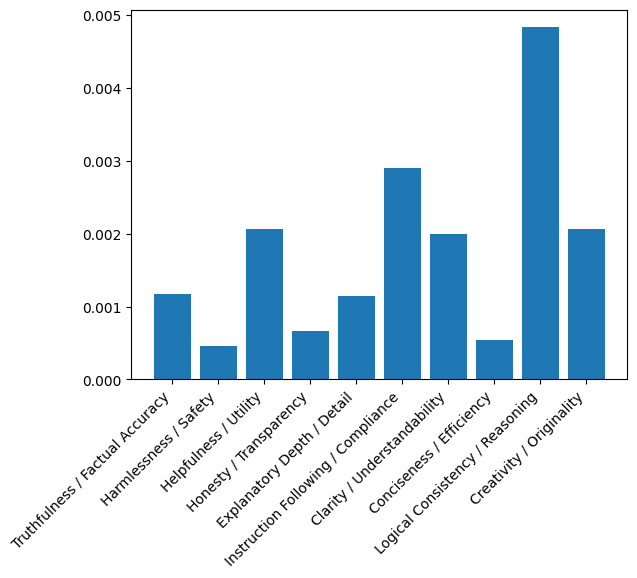

In [17]:
# ran for globally trained, looks simillar across
mean_scores, var_scores = importance_scores_by_cat(data, "Text Generation")
mean_scores, var_scores = importance_scores_by_cat(data, "Code Generation")


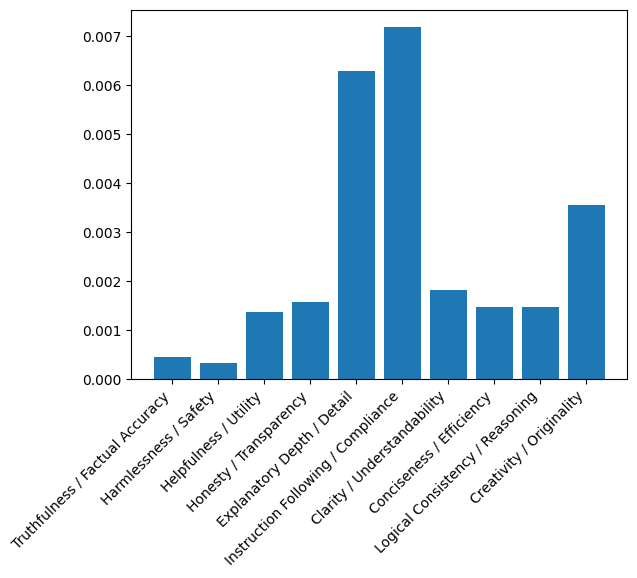

In [ ]:

mean_scores, var_scores = importance_scores_by_cat(data, "Text Generation")


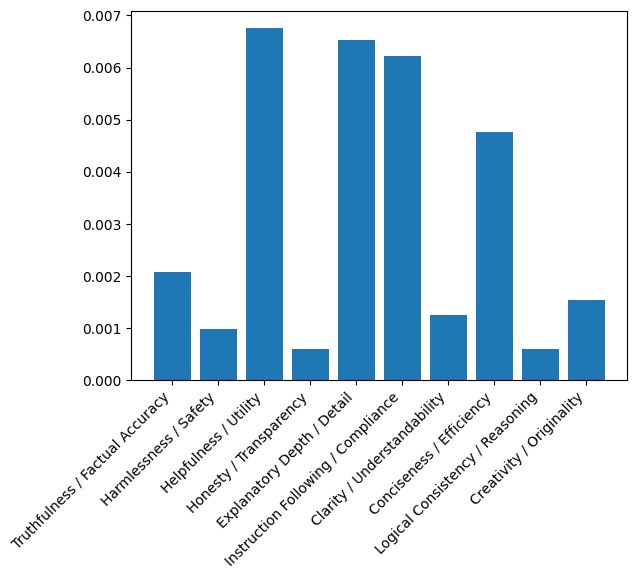

In [171]:
mean_scores, var_scores = importance_scores_by_cat(data, "Code Generation")


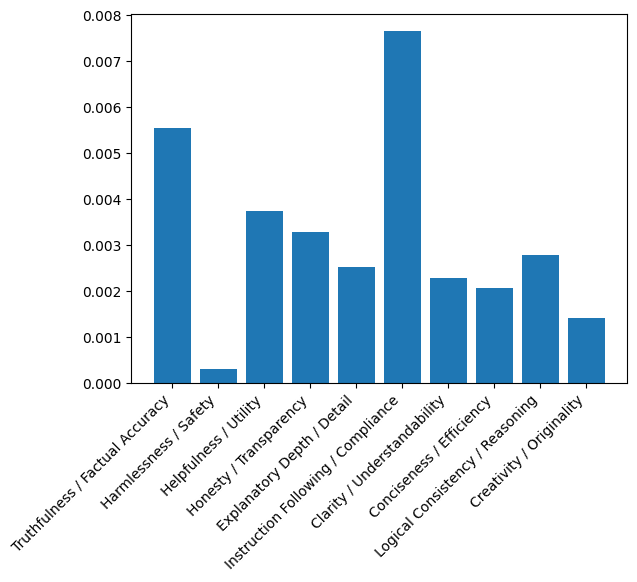

In [184]:
mean_scores, var_scores = importance_scores_by_cat(data, "Closed QA")


In [188]:
data[data['category']=="Closed QA"]['instruction'].values[:100]

array(['[Q]: The answer to the question: What is the name of the character whose fertilized egg was replaced with one of Helen\'s? is inside the article: After struggling with infertility, Anne finally succeeds in getting pregnant through invitro fertilization with her husband Jack. However, one night, Anne awakens to discover a masked intruder in her room. Terrified, Anne tries to escape, but the intruder chloroforms her into unconsciousness, rendering her helpless as he kidnaps her and takes her to an isolated house. In the morning, Anne finds herself held captive by a couple named Frank and Helen. Helen has gone mad after her baby was aborted by Frank upon learning that it would have been born deformed. The procedure left her sterile, and he is now attempting to make it up to her by giving her Anne\'s baby. Anne recognizes Frank as a technician at her fertility clinic, and Helen later tells her that he secretly replaced her fertilized egg with one of Helen\'s instead. Frank stages a

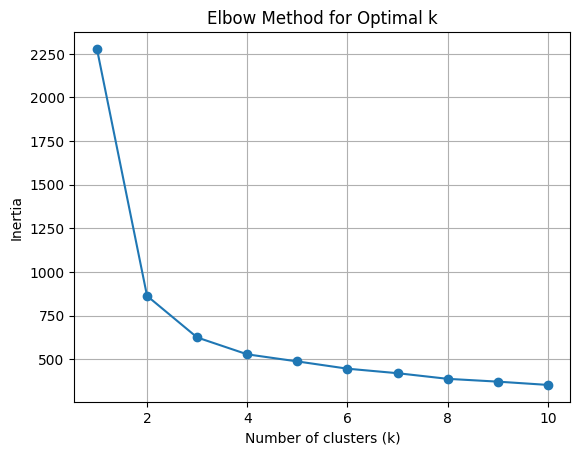

In [142]:
# cluster df based on attributions
from sklearn.cluster import KMeans
X = np.array(data['attributions'].tolist())
inertia = []
K = range(1, 11)  # Test k values from 1 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()



kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

data['attribution_cluster'] = clusters
# code to pick k based on elbow method and silhouette score


# from sklearn.cluster import AgglomerativeClustering

# # Cosine-based clustering
# clustering = AgglomerativeClustering(
#     n_clusters=4, 
#     metric='cosine', 
#     linkage='average'
# )
# clusters = clustering.fit_predict(attributions)
# data['attribution_cluster'] = clusters


In [151]:
data[data['attribution_cluster'] == 0]['instruction'].values[:100]

array(['[Q]: The answer to the question: What is the name of the character whose fertilized egg was replaced with one of Helen\'s? is inside the article: After struggling with infertility, Anne finally succeeds in getting pregnant through invitro fertilization with her husband Jack. However, one night, Anne awakens to discover a masked intruder in her room. Terrified, Anne tries to escape, but the intruder chloroforms her into unconsciousness, rendering her helpless as he kidnaps her and takes her to an isolated house. In the morning, Anne finds herself held captive by a couple named Frank and Helen. Helen has gone mad after her baby was aborted by Frank upon learning that it would have been born deformed. The procedure left her sterile, and he is now attempting to make it up to her by giving her Anne\'s baby. Anne recognizes Frank as a technician at her fertility clinic, and Helen later tells her that he secretly replaced her fertilized egg with one of Helen\'s instead. Frank stages a

In [148]:
data[data['attribution_cluster'] == 1]['instruction'].values

array(['In a Latex document, I want to include a direct speech sentence that Mary said. How can I format it correctly using quotation marks and punctuation?',
       'Generate response to the question/instruction based on a piece of given material\n\nQuestion/Instruction: Can you translate the text material into Spanish?\n\nGiven material: TD pass to Golden Tate.\nfirst downs were the fewest.\nbe back sooner than that.',
       "Detailed Instructions: In this task you will be given a string that only contains single digit numbers spelled out. The input string will not contain spaces between the different numbers. Your task is to return the number that the string spells out. The string will spell out each digit of the number for example '1726' will be 'oneseventwosix' instead of 'one thousand seven hundred six'.\nQ: zeroonesixtwoeightfourtwothree\nA:",
       'Teacher: In this task your given two statements. You must judge whether the second sentence is the cause or effect of the first 

c:\Users\dhruv\Documents\judge-aggregator\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

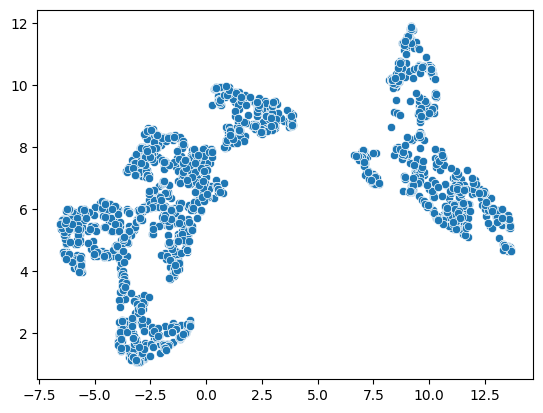

In [141]:
from umap.umap_ import UMAP
import seaborn as sns
X_umap = UMAP(random_state=0).fit_transform(X)
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1])

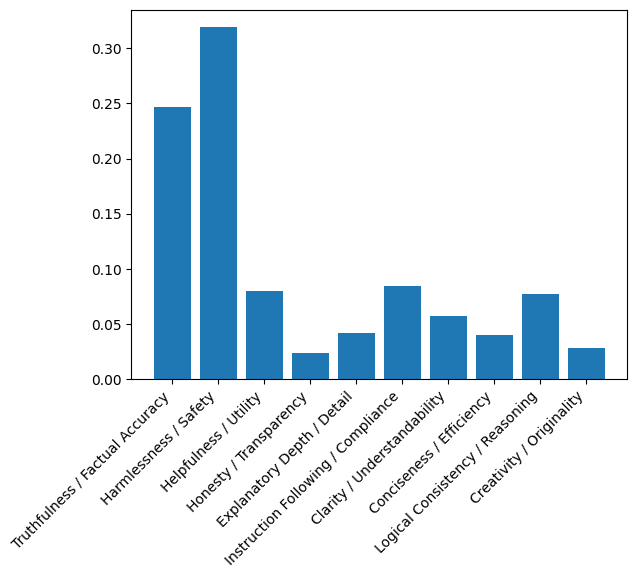

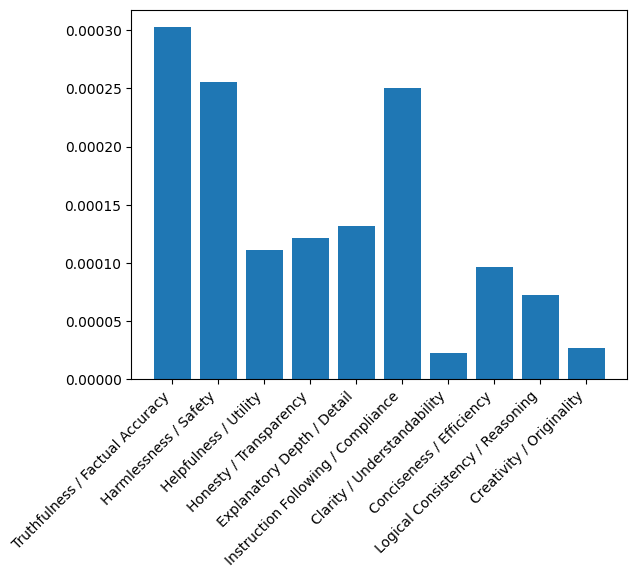

In [21]:
mean_scores, var_scores = importance_scores(data[data['attribution_cluster'] == 0])


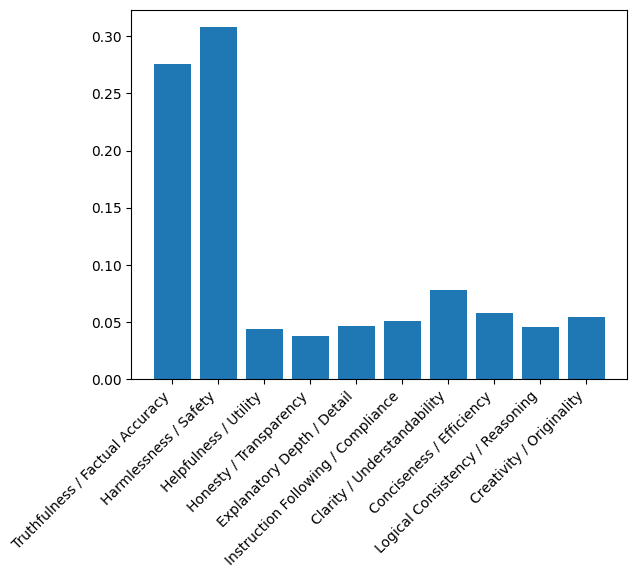

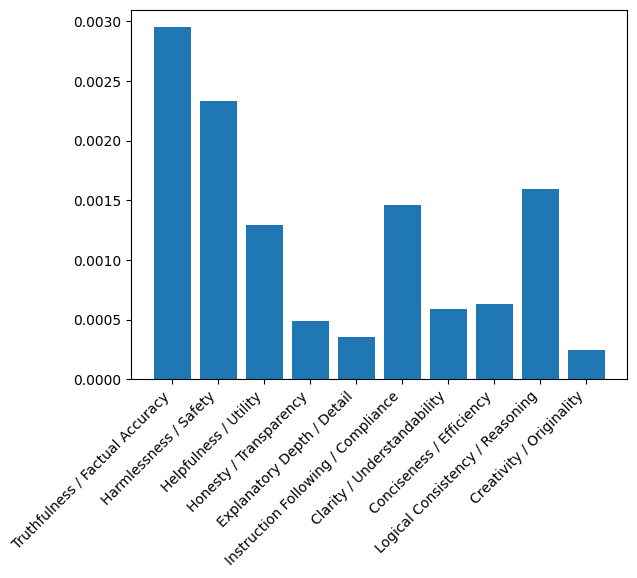

In [22]:
mean_scores, var_scores = importance_scores(data[data['attribution_cluster'] == 1])


In [23]:
data[data['attribution_cluster'] == 1].loc[0:100, "instruction"].values

array(['In a Latex document, I want to include a direct speech sentence that Mary said. How can I format it correctly using quotation marks and punctuation?',
       'Teacher: In this task your given two statements. You must judge whether the second sentence is the cause or effect of the first one. Label the instances as "cause" or "effect" based on your judgment. The sentences are separated by a newline character.\nTeacher: Now, understand the problem? If you are still confused, see the following example:\nThe women met for coffee.\nThey wanted to catch up with each other.\nSolution: cause\nReason: The women met for coffee because they wanted to catch up with each other.\n\nNow, solve this instance: The family lost all their belongings.\nTheir house caught fire.\nStudent:',
       "In this task, answer 'Yes' if the frequency of the given word in the two sentences is equal, else answer 'No'.\nQ: Sentence1: 'a boy in a white tank top biting a white frisbee', Sentence2: 'a little girl ho

In [24]:
data[data['attribution_cluster'] == 0].loc[0:100, "instruction"].values

array(['[Q]: The answer to the question: What is the name of the character whose fertilized egg was replaced with one of Helen\'s? is inside the article: After struggling with infertility, Anne finally succeeds in getting pregnant through invitro fertilization with her husband Jack. However, one night, Anne awakens to discover a masked intruder in her room. Terrified, Anne tries to escape, but the intruder chloroforms her into unconsciousness, rendering her helpless as he kidnaps her and takes her to an isolated house. In the morning, Anne finds herself held captive by a couple named Frank and Helen. Helen has gone mad after her baby was aborted by Frank upon learning that it would have been born deformed. The procedure left her sterile, and he is now attempting to make it up to her by giving her Anne\'s baby. Anne recognizes Frank as a technician at her fertility clinic, and Helen later tells her that he secretly replaced her fertilized egg with one of Helen\'s instead. Frank stages a

### Input-wise breakdown

#### Closed QA

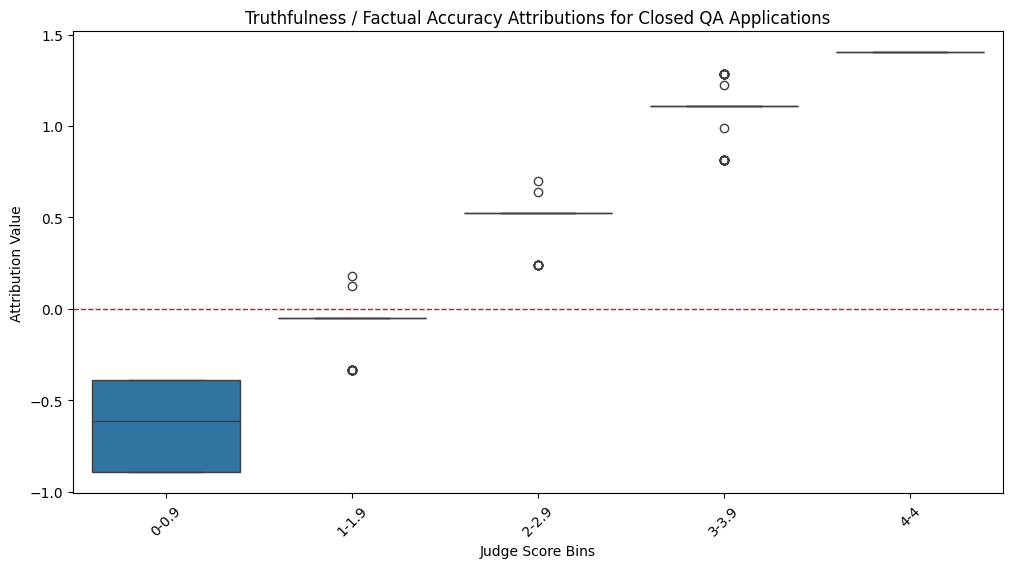

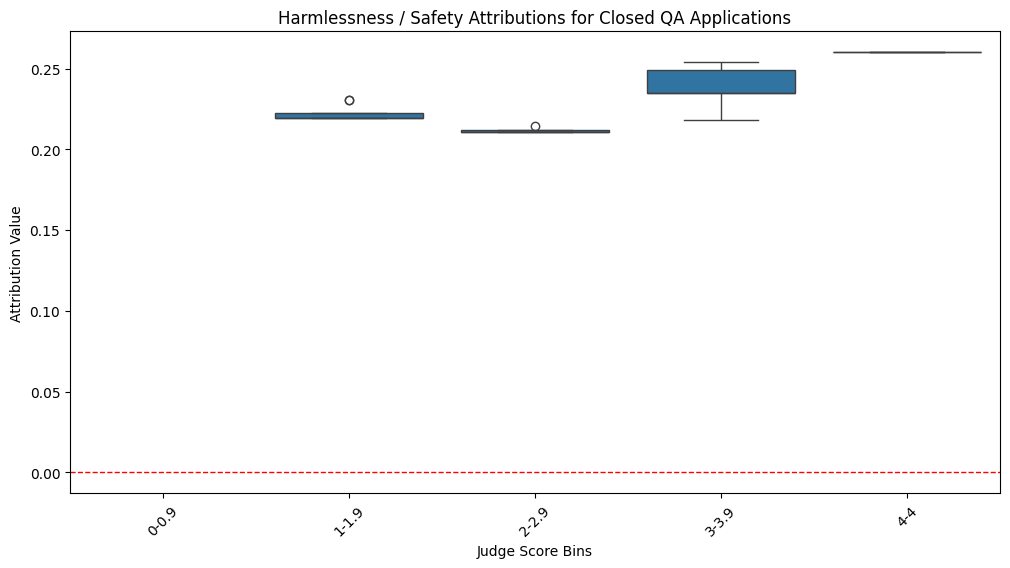

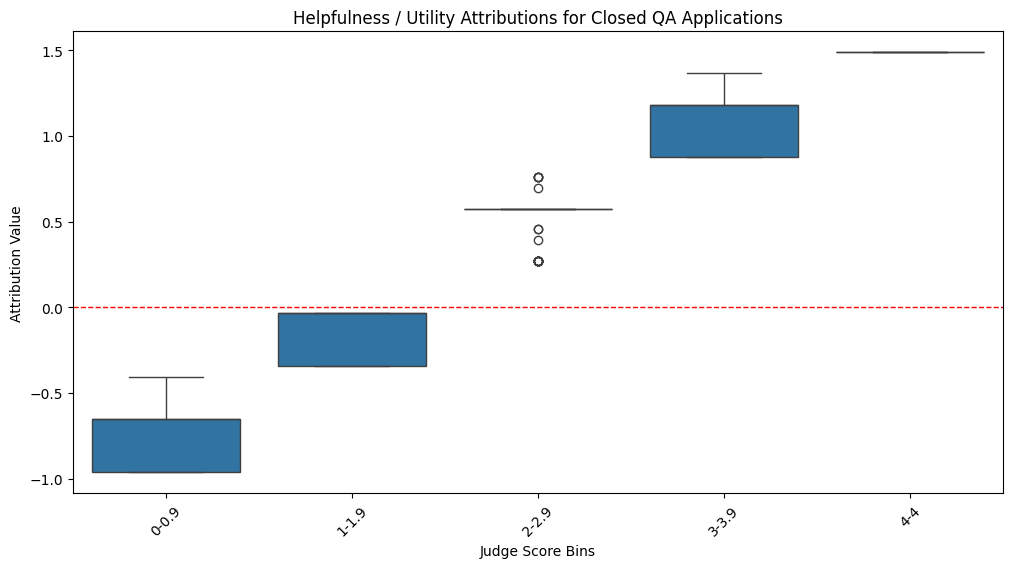

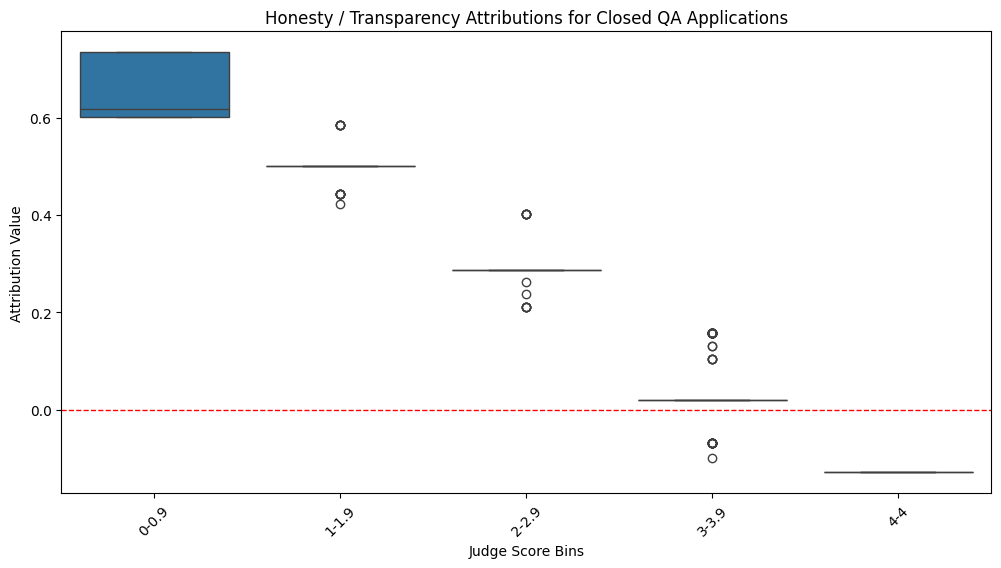

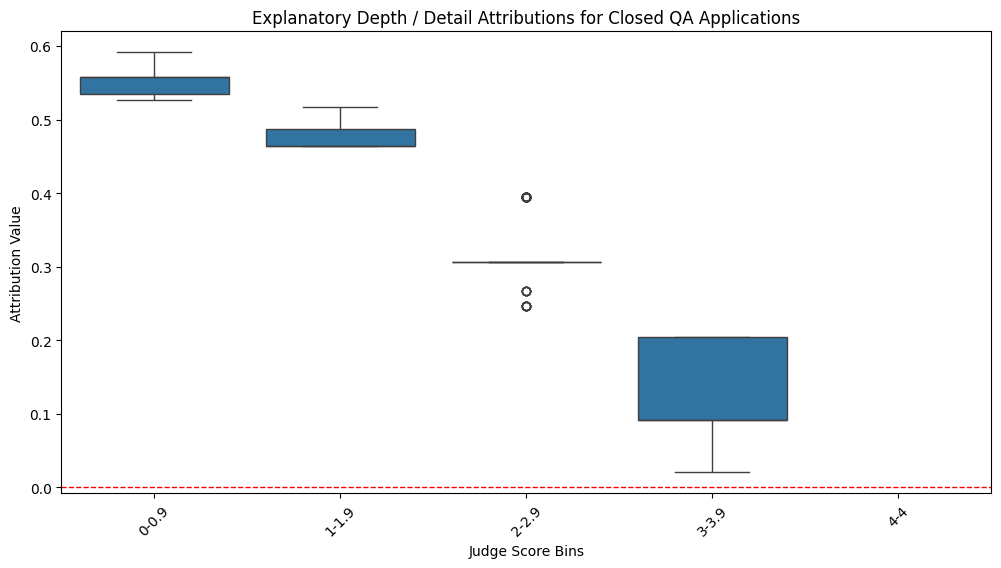

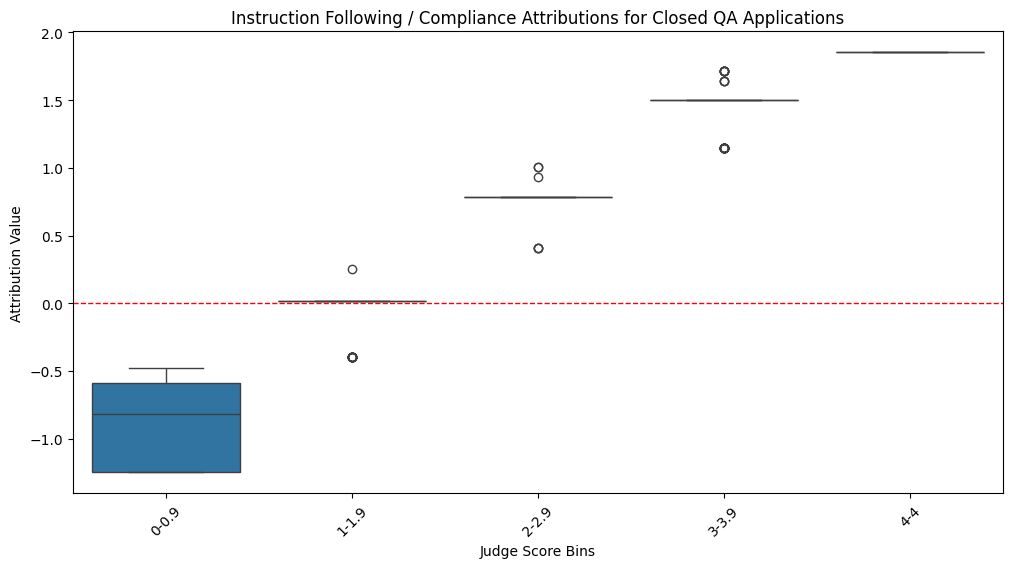

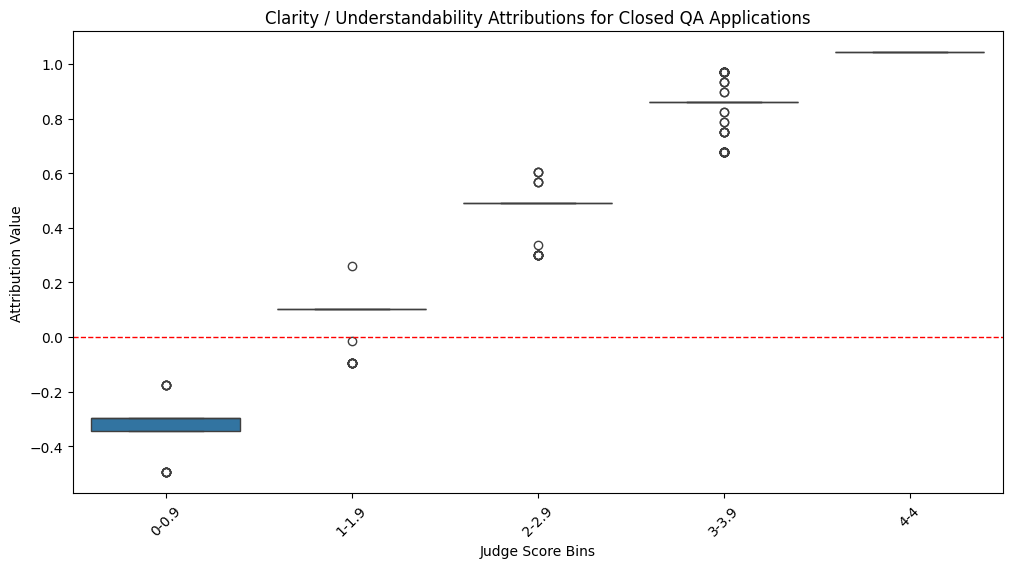

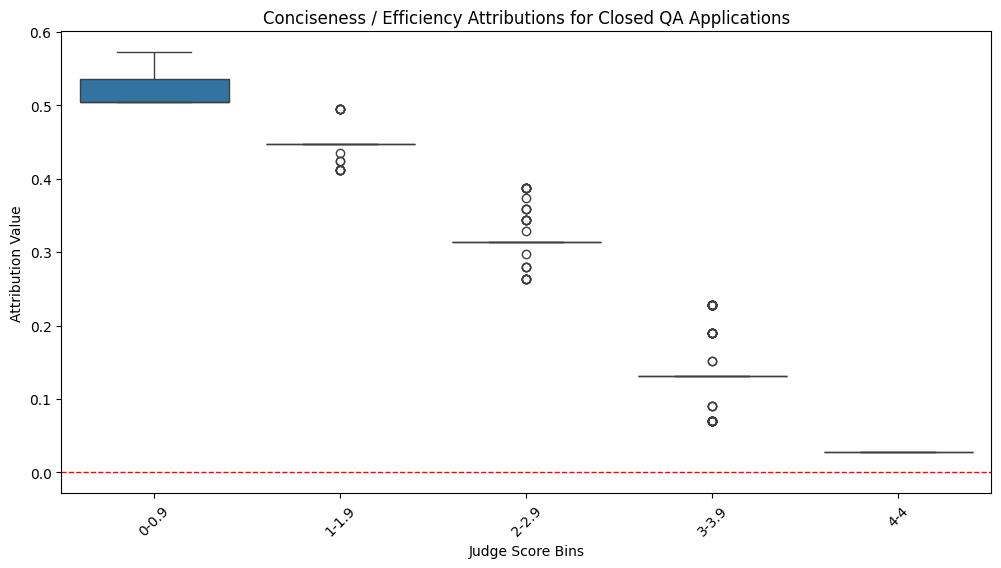

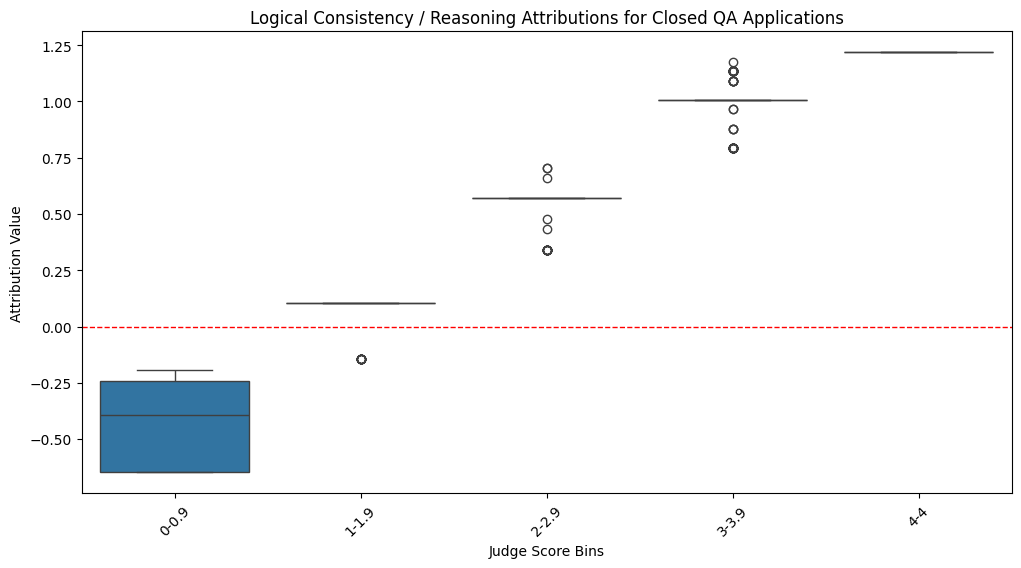

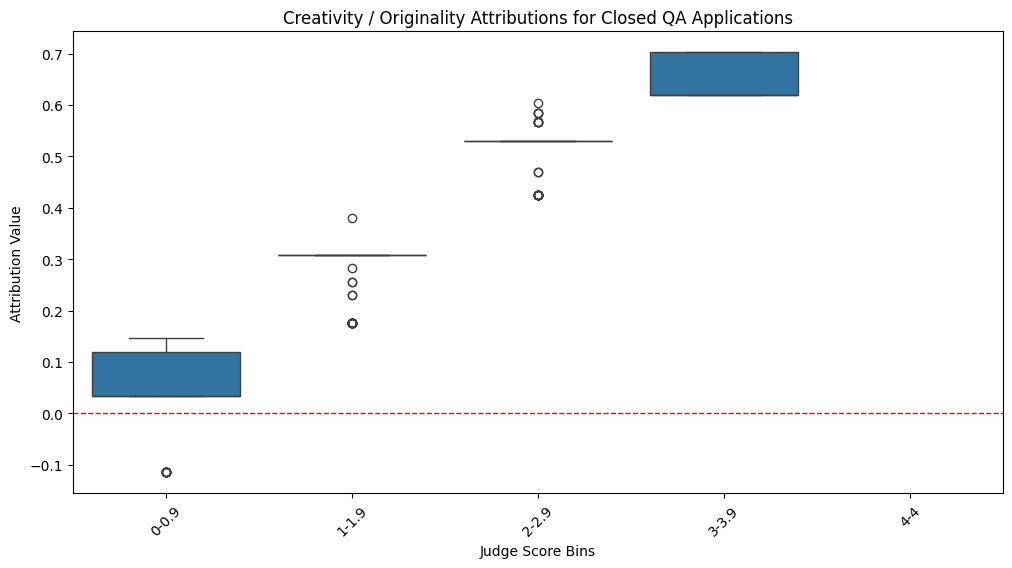

In [ ]:
from scipy.stats import spearmanr

def breakdown_plot_by_category(data, subset_to_analyze, judges_names):
    data_subset = data[data['category'] == subset_to_analyze]
    bin_edges = [0, 1, 2, 3, 4, 5]
    bin_labels = ['0-0.9', '1-1.9', '2-2.9', '3-3.9', '4-4']
    spearman_correlations = []
    p_values = []
    deltas = []
    starts = []
    ends = []
    for feature in range(len(data['judge_scores'].iloc[0])):
        bins  = pd.cut(
            data_subset['judge_scores'].apply(lambda x: x[feature]), 
            bins=bin_edges, 
            labels=bin_labels, 
            include_lowest=True, 
            right=False
        )
        attribs = data_subset['attributions'].apply(lambda x: x[feature])
        # print(attribs)
        median_attribs = attribs.groupby(bins.cat.codes).median().dropna()
        start = median_attribs.tolist()[0]
        end = median_attribs.tolist()[-1]
        starts.append(start)
        ends.append(end)
        delta =  end-start
        deltas.append(delta)
        corr, p_value = spearmanr(attribs, bins.cat.codes)
        p_values.append(p_value)
        spearman_correlations.append(corr)
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=bins, y=attribs)
        plt.title(f'{judges_names[feature]} Attributions for {subset_to_analyze} Applications')
        plt.xticks(rotation=45)
        plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Add horizontal line at y=0

        plt.ylabel('Attribution Value')
        plt.xlabel('Judge Score Bins')
        plt.show()
    table = pd.DataFrame({
        'Start Attribution': starts,
        'End Attribution': ends,
        'Delta': deltas,
        'Spearman Correlation': spearman_correlations,
        'P-Value': p_values
    })
    table.index = judges_names
 
    return table
# spearman_correlations = breakdown_plot_by_category(data, "Code Generation", list(params['feature_importance'].keys()))
# breakdown_summary_closed_qa = breakdown_plot_by_category(data, "Closed QA", list(params['feature_importance'].keys()))

#### Code Generation Plots

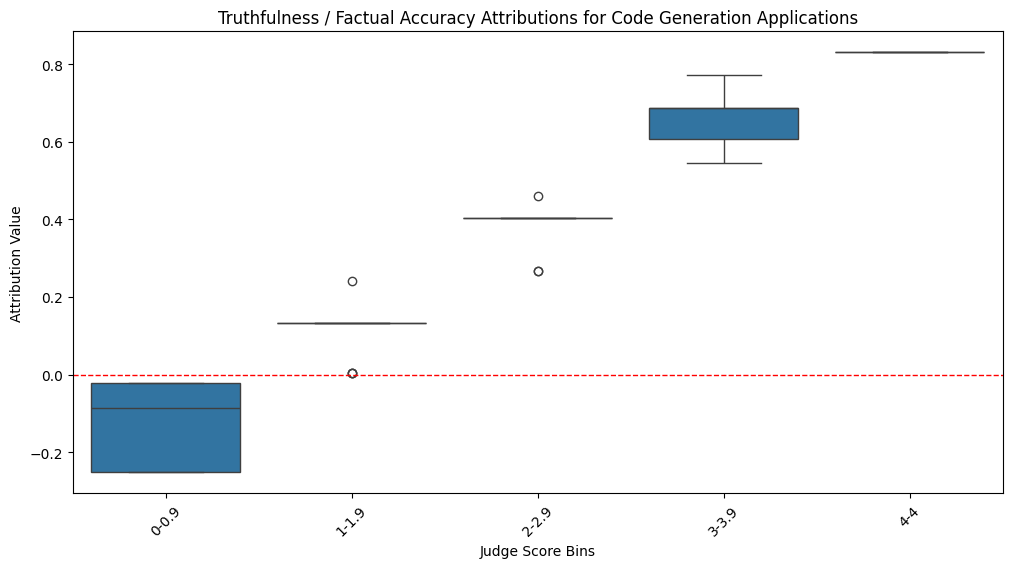

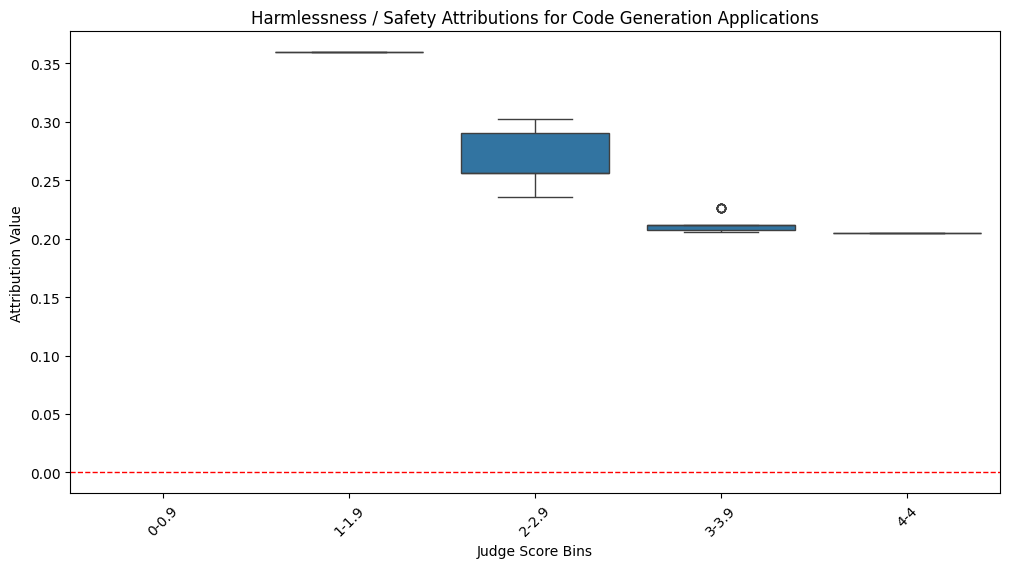

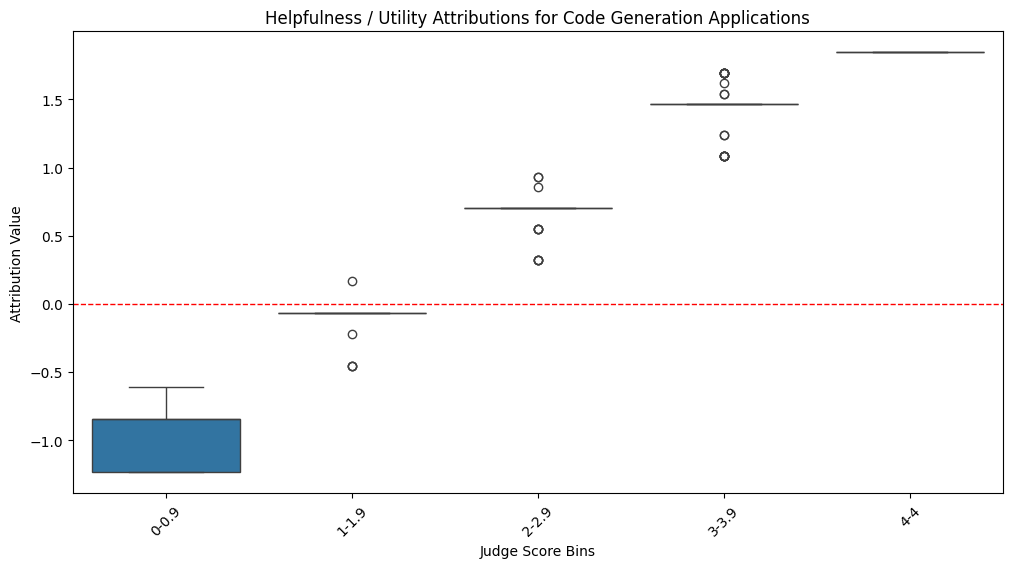

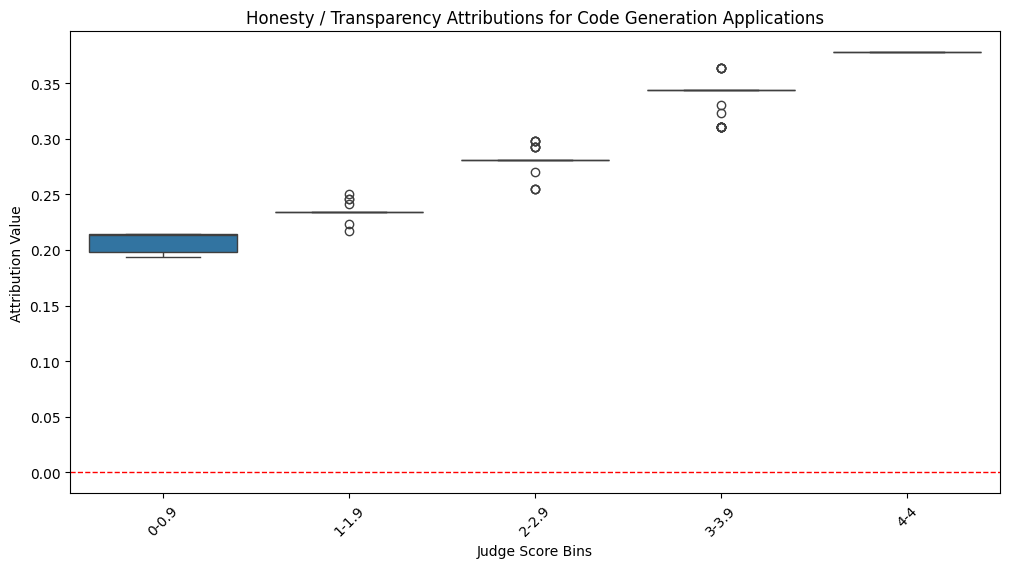

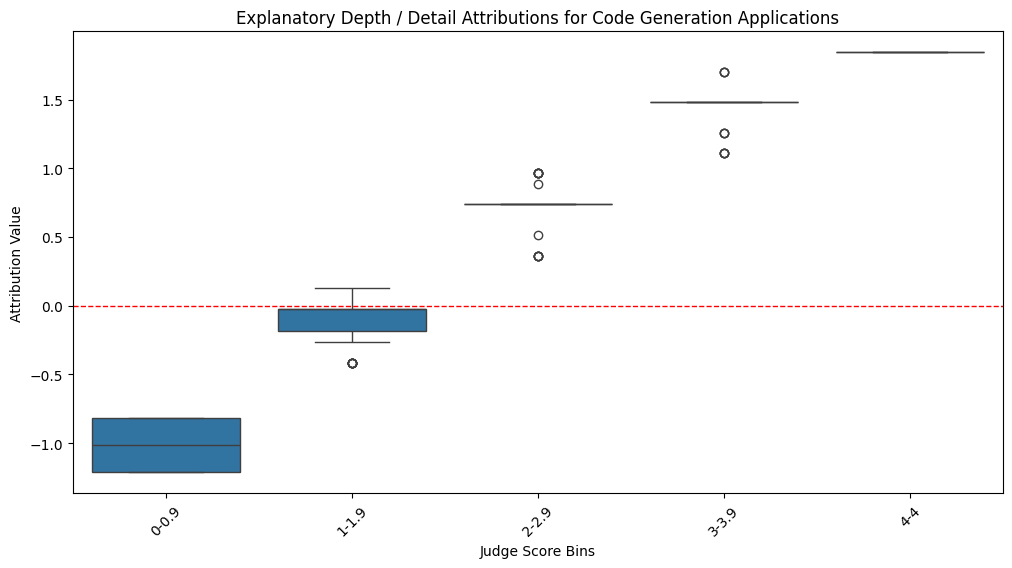

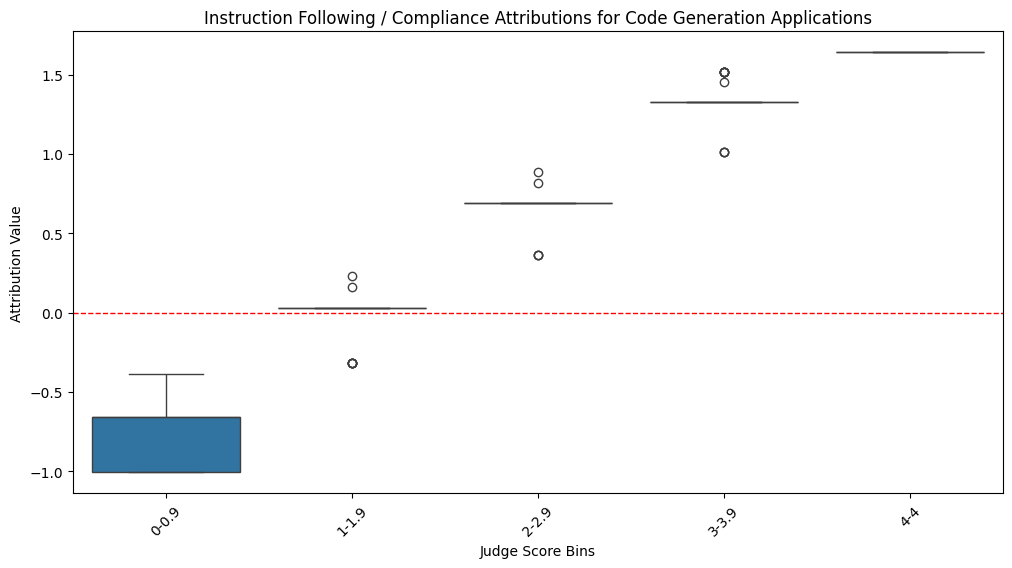

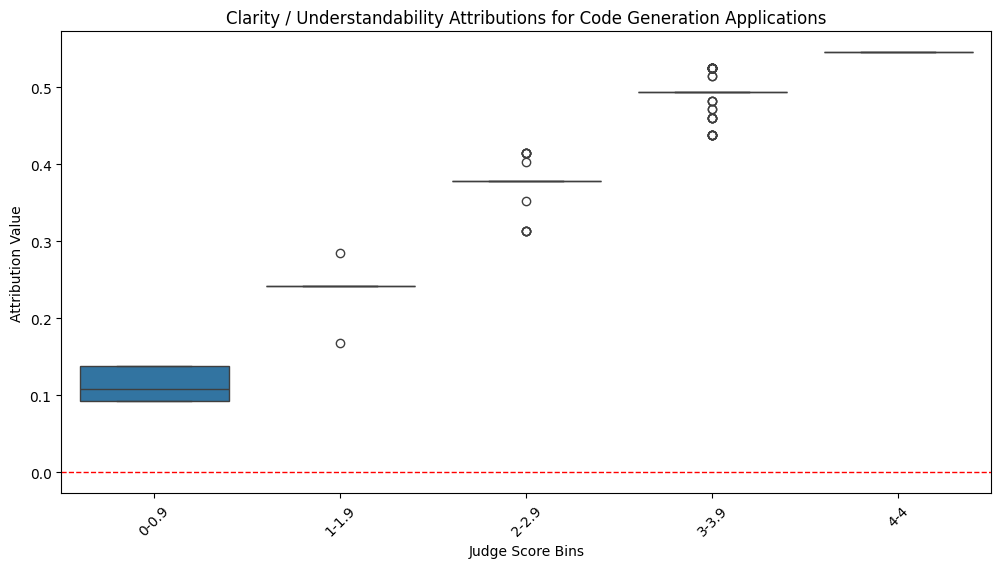

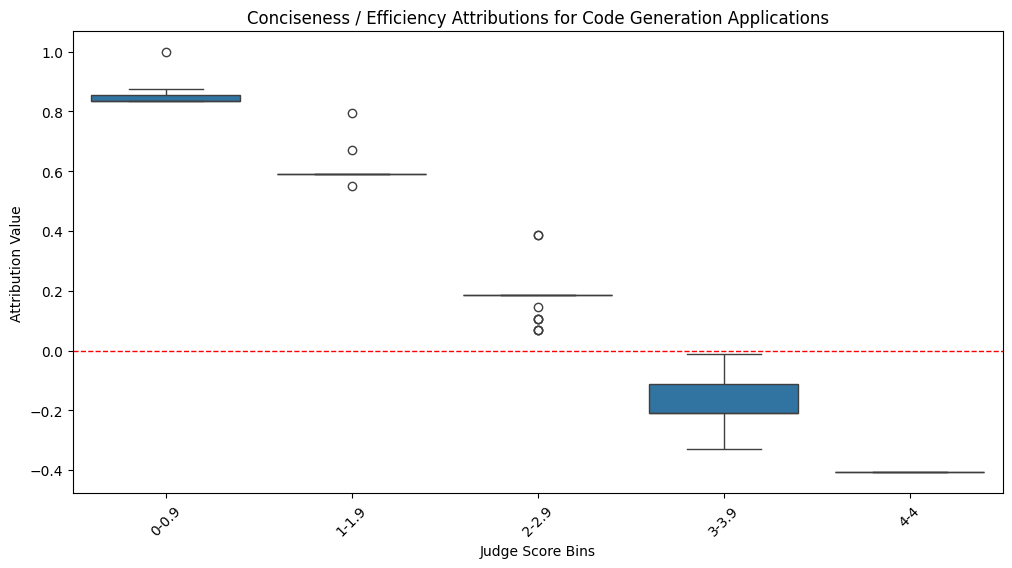

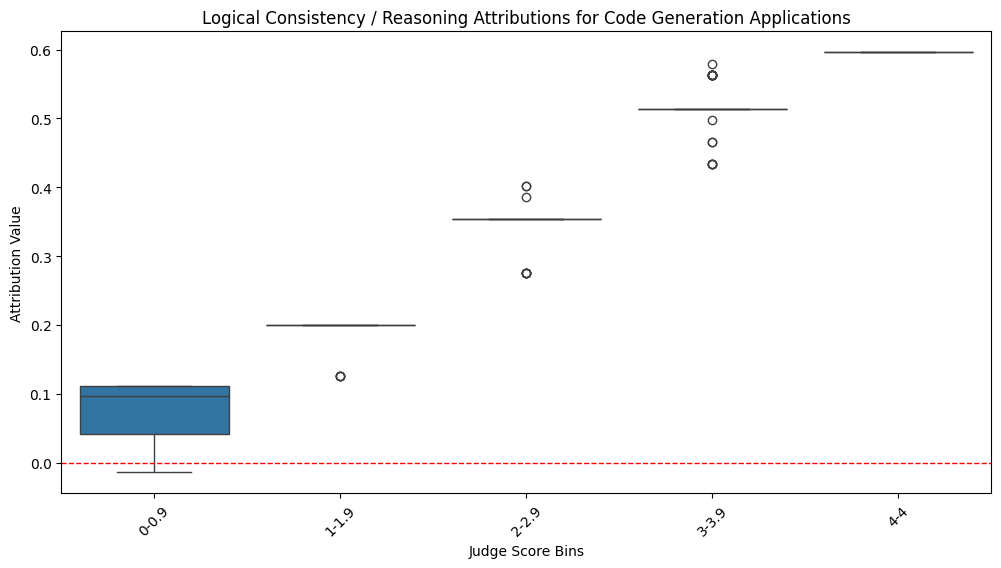

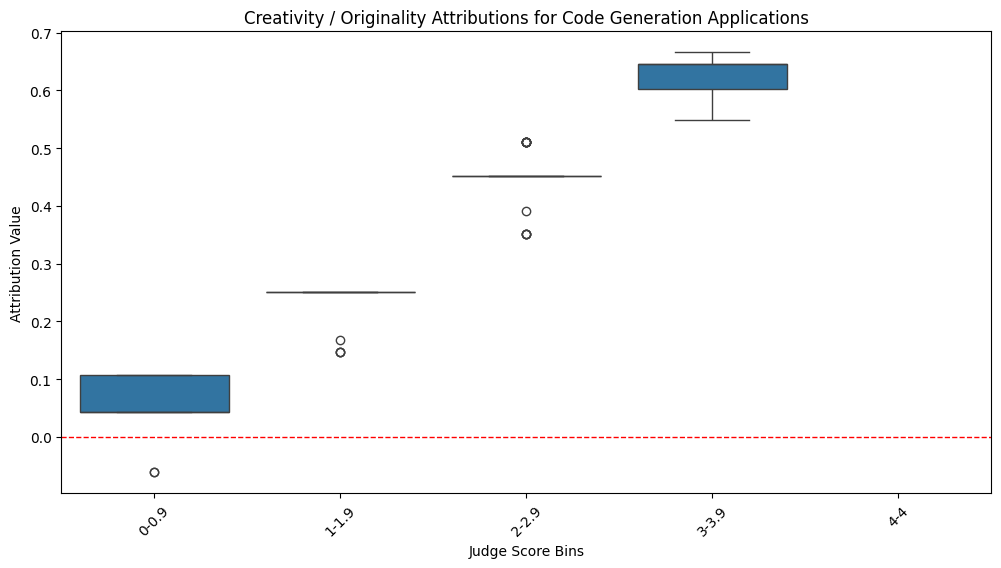

,Start Attribution,End Attribution,Delta,Spearman Correlation,P-Value
Truthfulness / Factual Accuracy,-0.086656,0.830050,0.916706,0.987102,7.099565e-115
Harmlessness / Safety,0.359390,0.204973,-0.154417,-0.922446,1.496720e-60
Helpfulness / Utility,-0.846386,1.845145,2.691530,0.972263,1.725988e-91
Honesty / Transparency,0.213287,0.377727,0.164440,0.968848,5.829064e-88
Explanatory Depth / Detail,-1.013679,1.844159,2.857839,0.971461,1.270764e-90
Instruction Following / Compliance,-0.660212,1.640032,2.300244,0.985945,3.035697e-112
Clarity / Understandability,0.108144,0.545333,0.437189,0.914588,1.067664e-57
Conciseness / Efficiency,0.833944,-0.407969,-1.241913,-0.966541,8.565252e-86
Logical Consistency / Reasoning,0.097790,0.595774,0.497984,0.969423,1.583094e-88
Creativity / Originality,0.043846,0.646371,0.602525,0.964581,4.554750e-84


In [199]:
breakdown_plot_by_category(data, "Code Generation", list(params['feature_importance'].keys()))

#### Text Generation

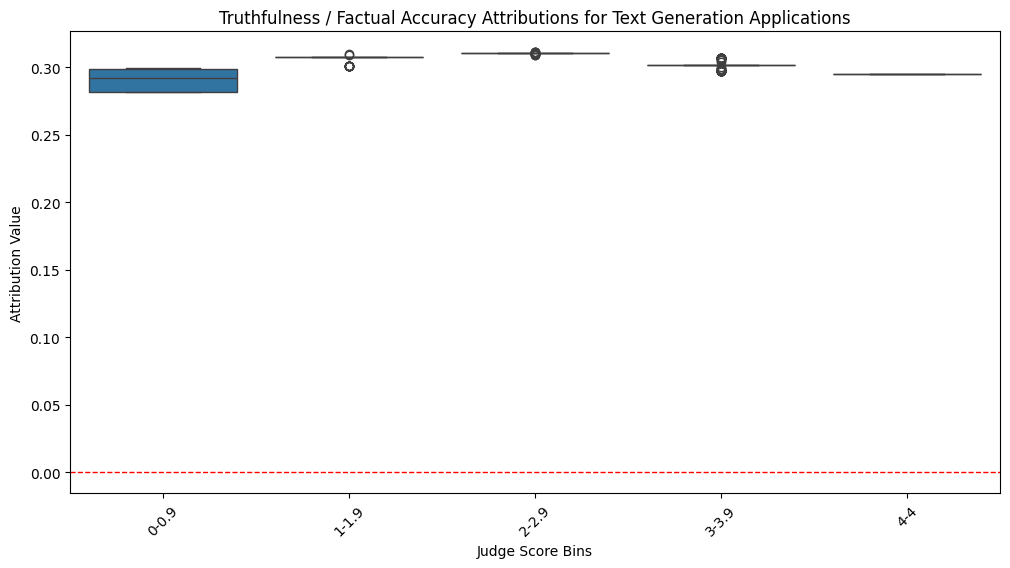

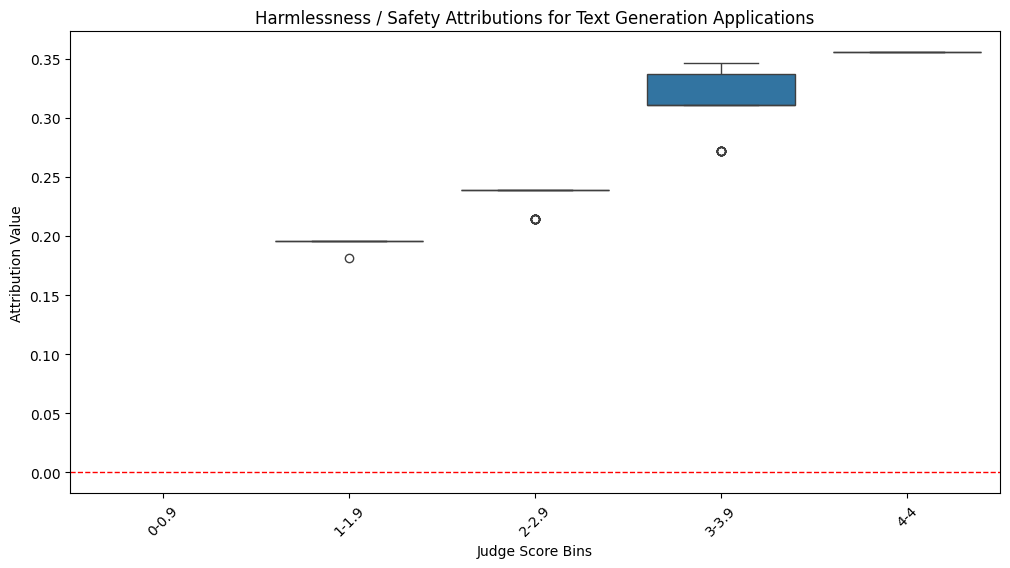

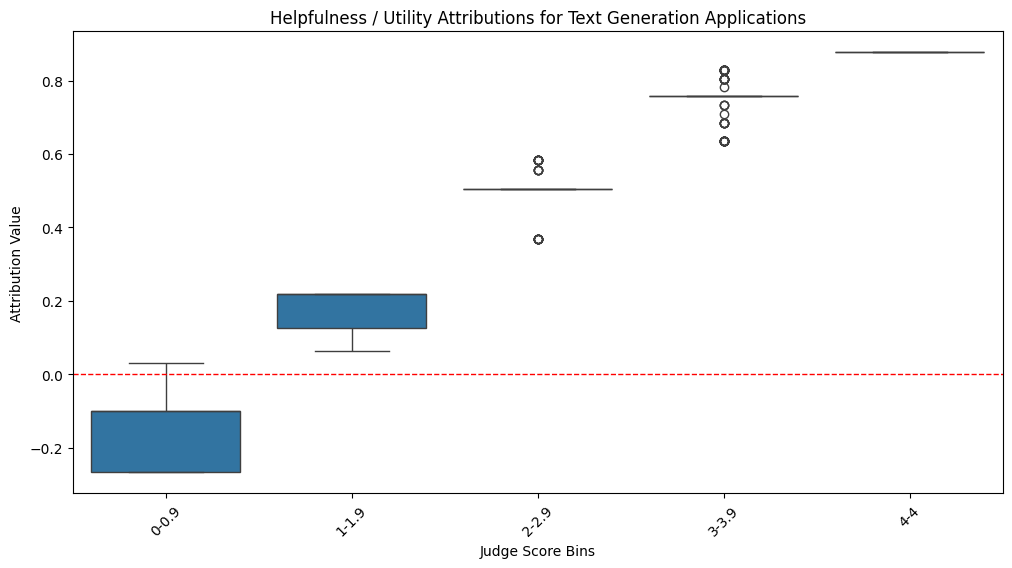

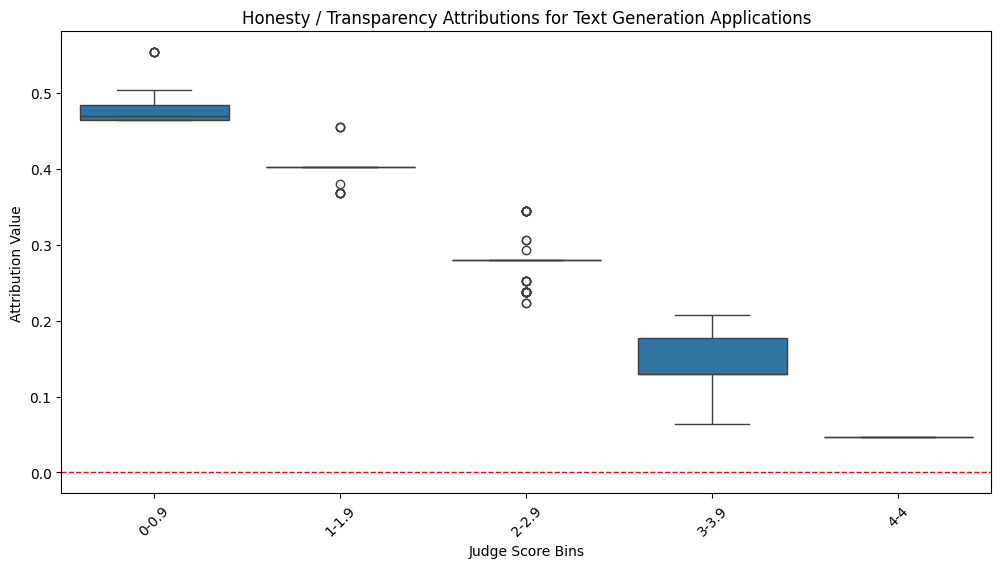

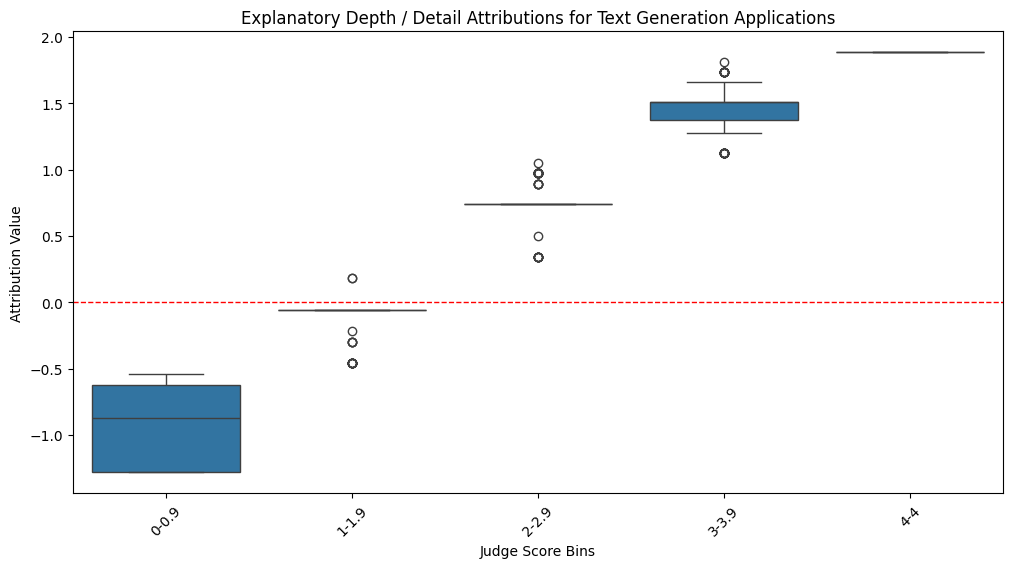

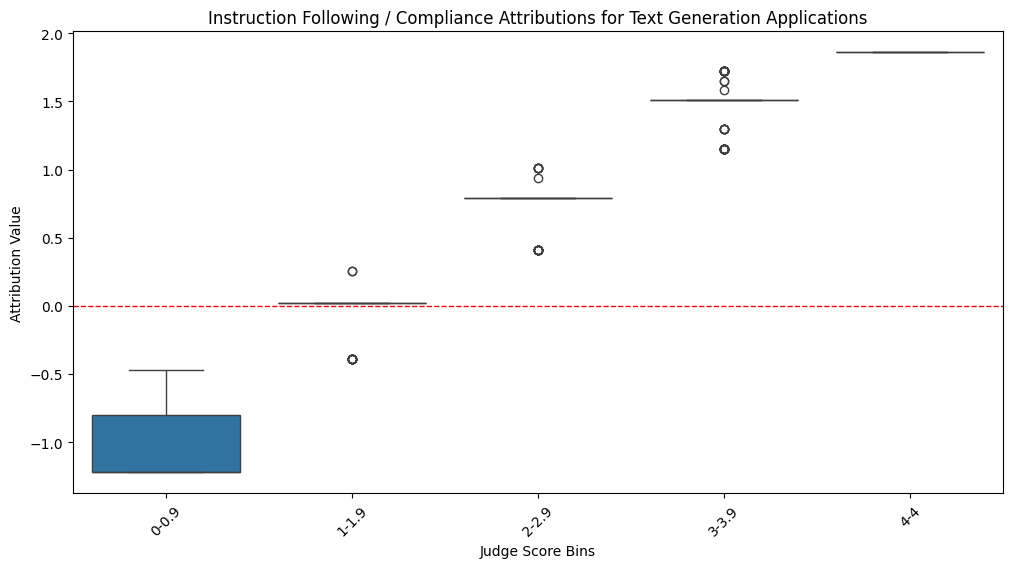

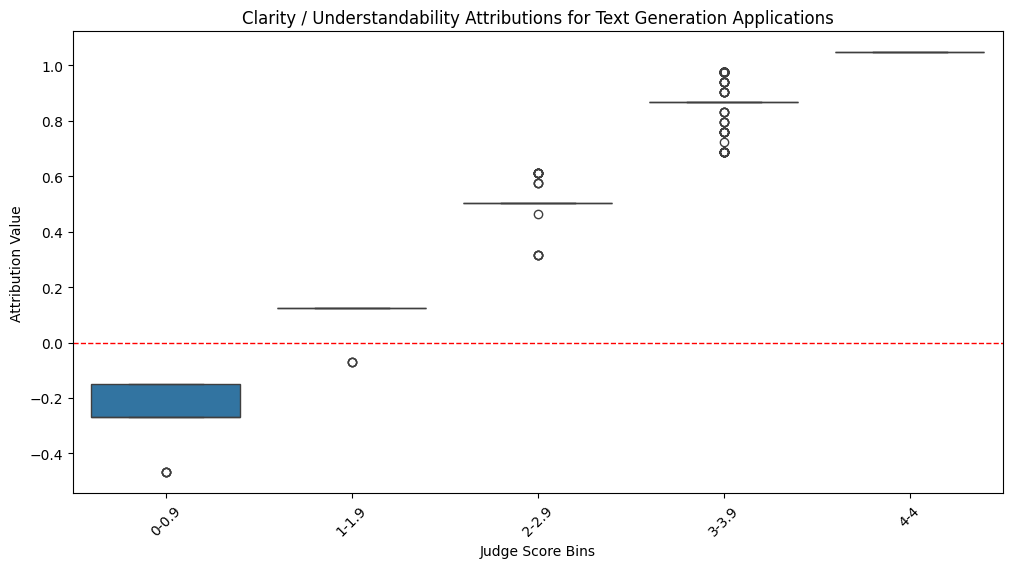

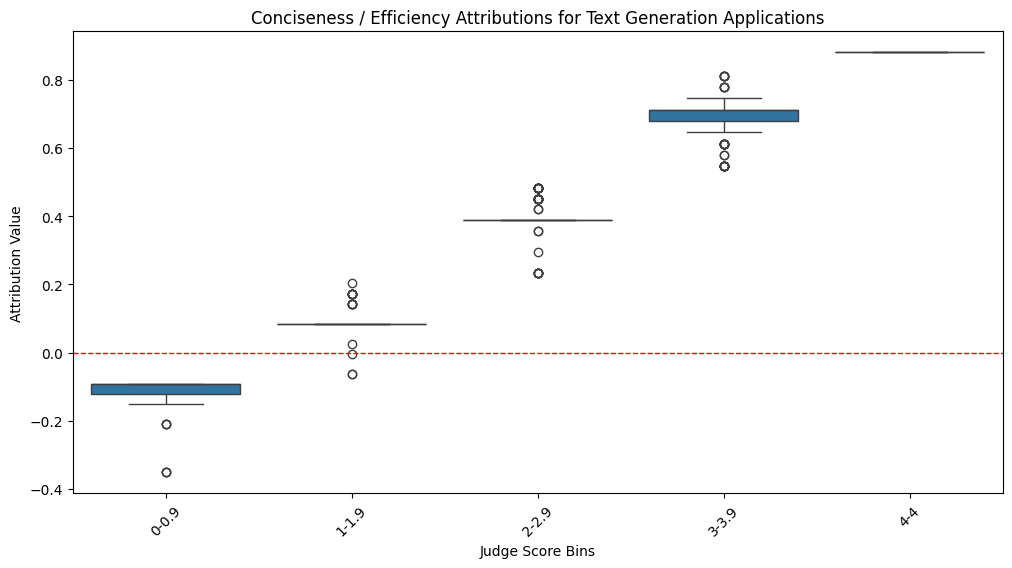

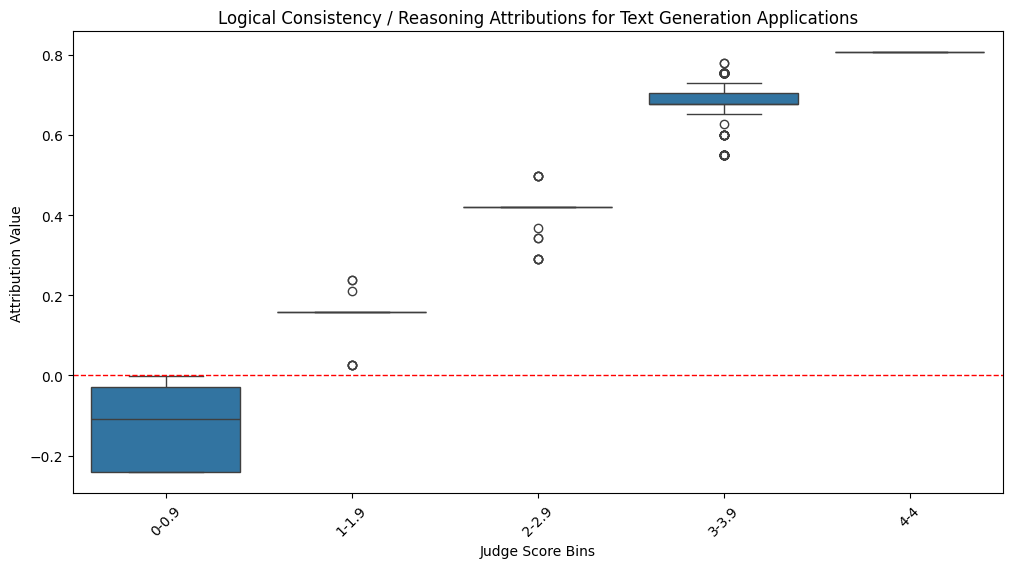

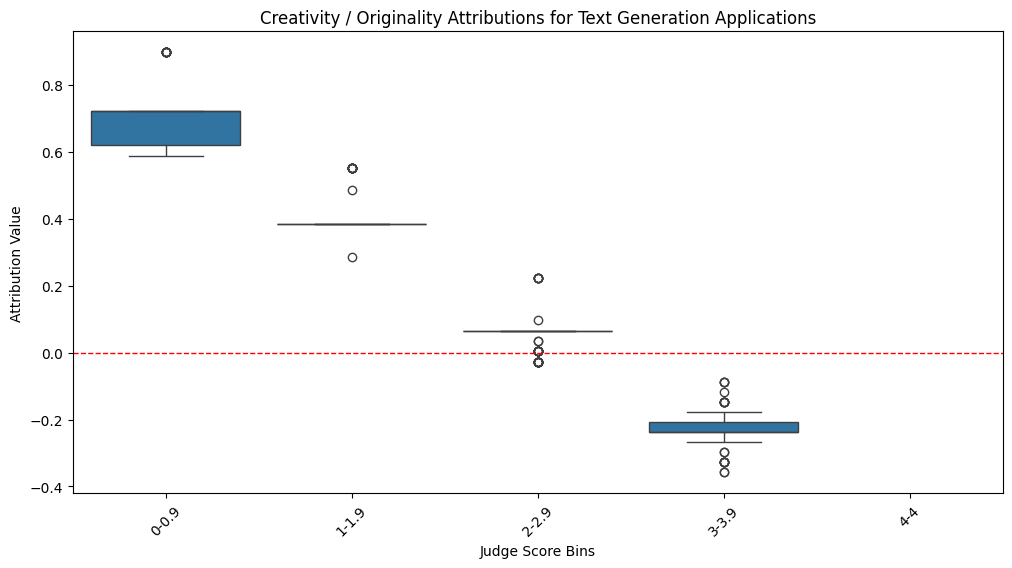

,Start Attribution,End Attribution,Delta,Spearman Correlation,P-Value
Truthfulness / Factual Accuracy,0.292225,0.294966,0.002741,-0.526341,1.398508e-32
Harmlessness / Safety,0.196219,0.355349,0.159130,0.931849,4.478432e-194
Helpfulness / Utility,-0.100276,0.876464,0.976740,0.960004,3.558507e-243
Honesty / Transparency,0.469498,0.046532,-0.422966,-0.962342,9.102610e-249
Explanatory Depth / Detail,-0.871120,1.883869,2.754989,0.969700,5.342380e-269
Instruction Following / Compliance,-1.222249,1.859751,3.082001,0.980469,4.613973e-310
Clarity / Understandability,-0.269589,1.046850,1.316440,0.912940,8.170466e-172
Conciseness / Efficiency,-0.092662,0.880161,0.972822,0.966072,1.830930e-258
Logical Consistency / Reasoning,-0.108236,0.806256,0.914492,0.906839,1.061565e-165
Creativity / Originality,0.723171,-0.238369,-0.961540,-0.970006,6.057218e-270


In [206]:
breakdown_plot_by_category(data, "Text Generation", list(params['feature_importance'].keys()))

#### Code Generation Plots (OLD)

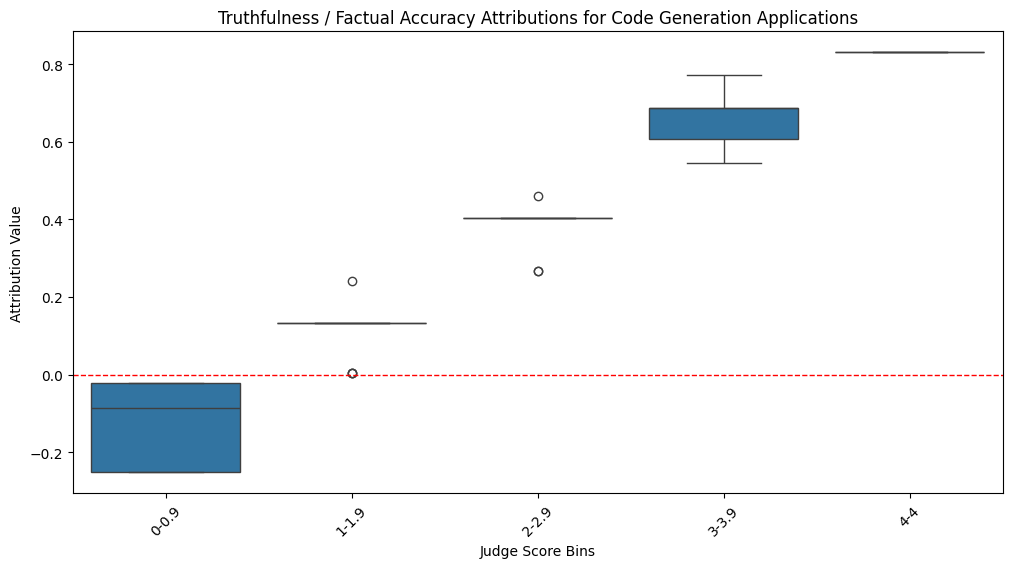

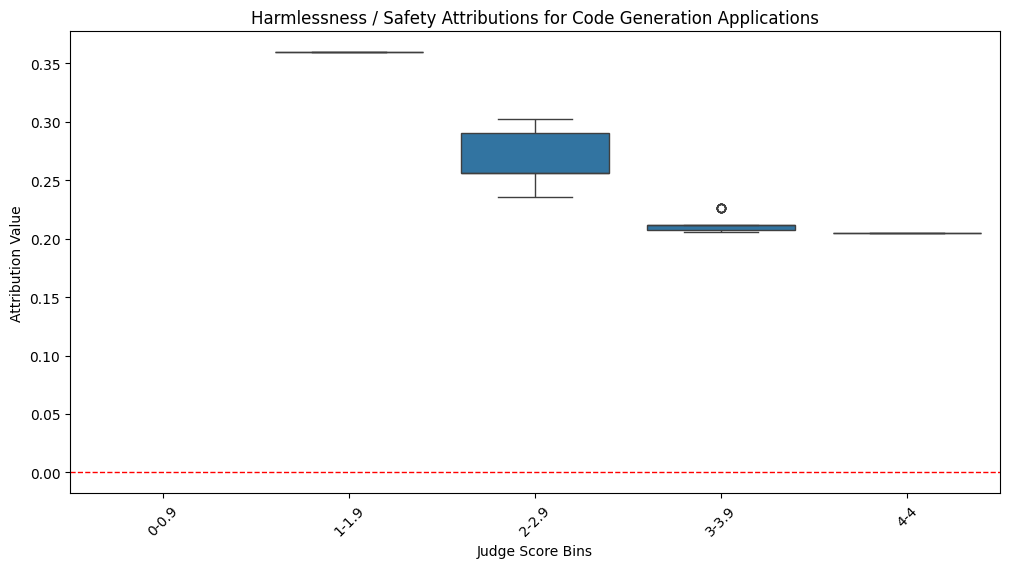

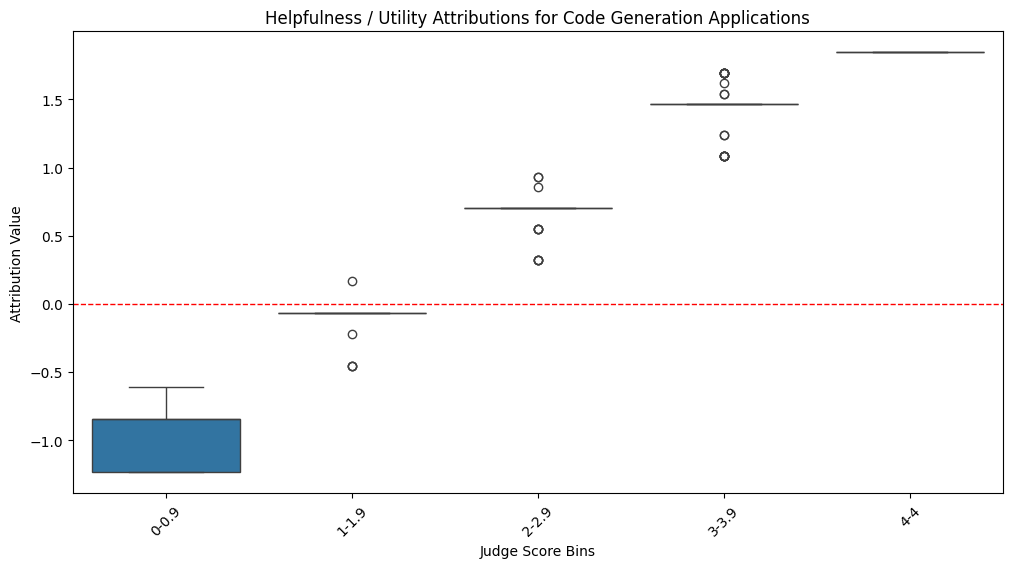

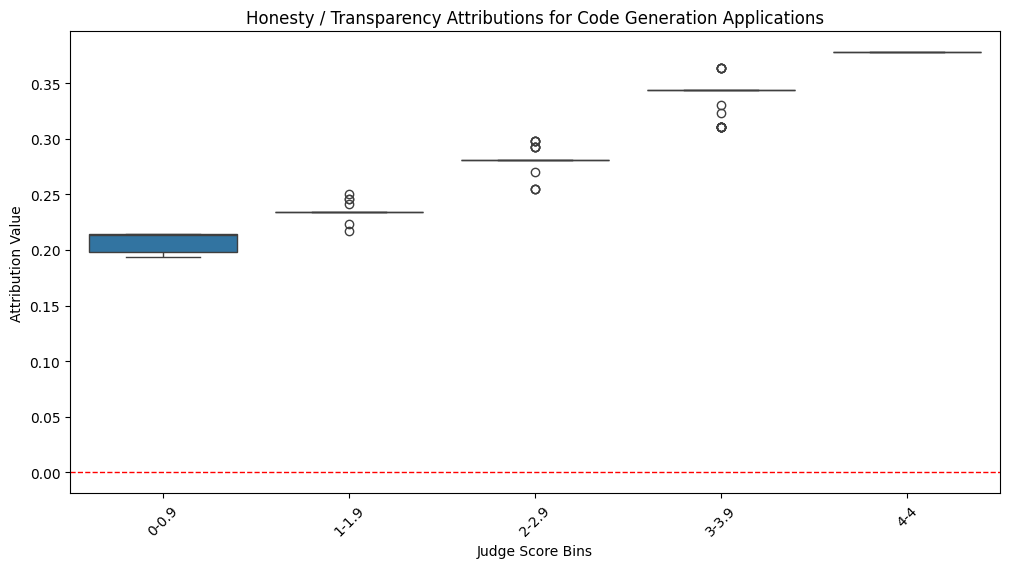

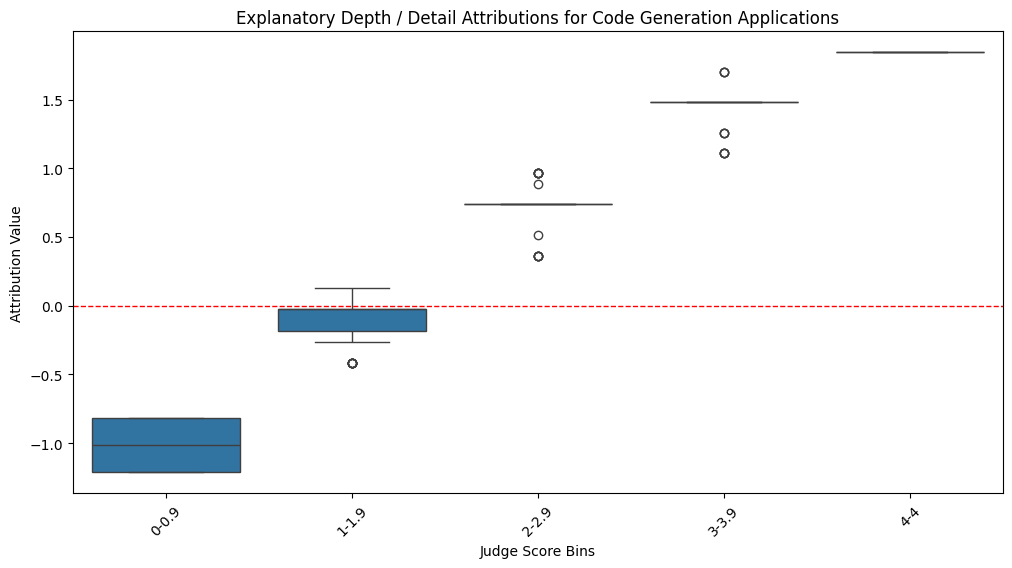

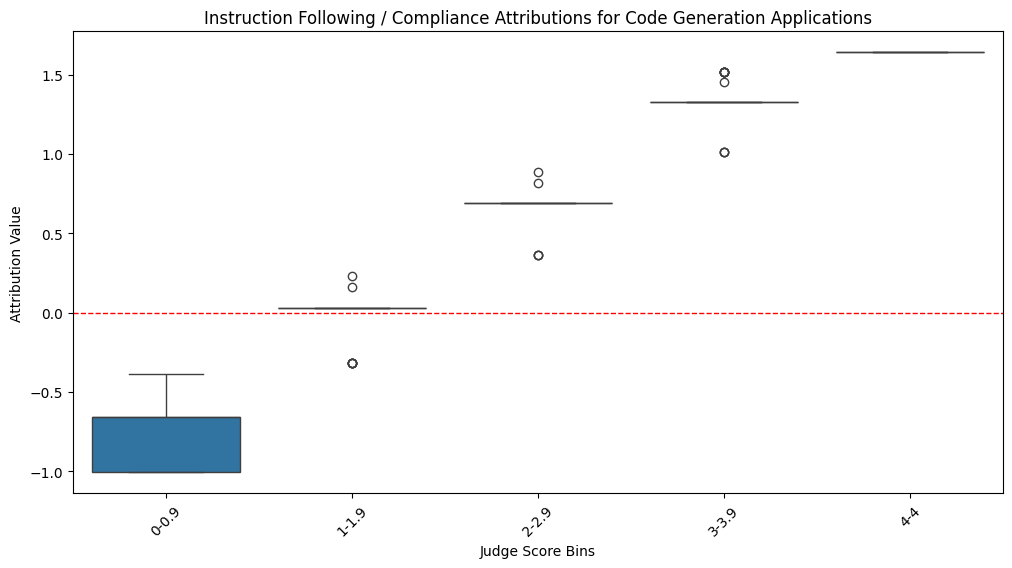

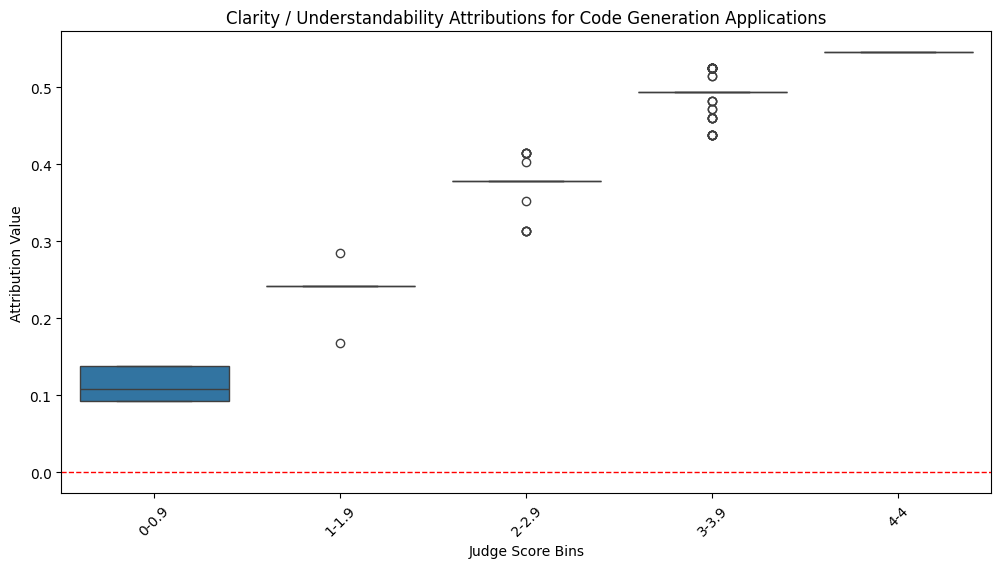

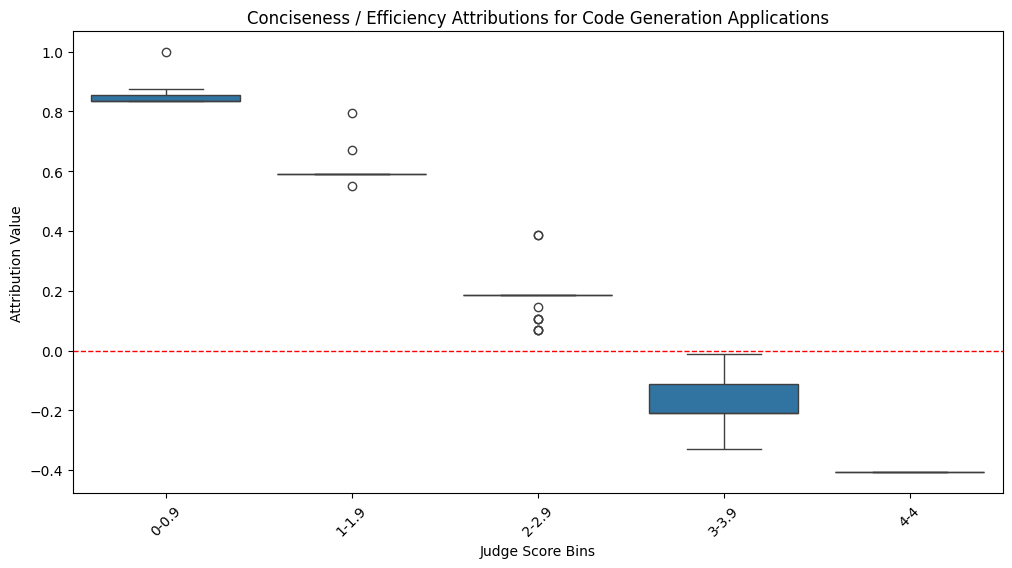

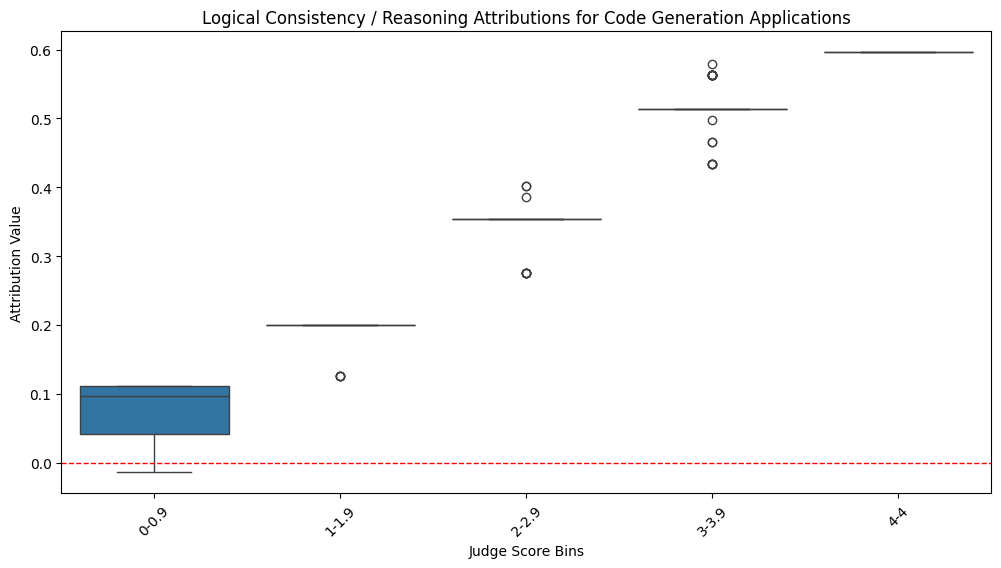

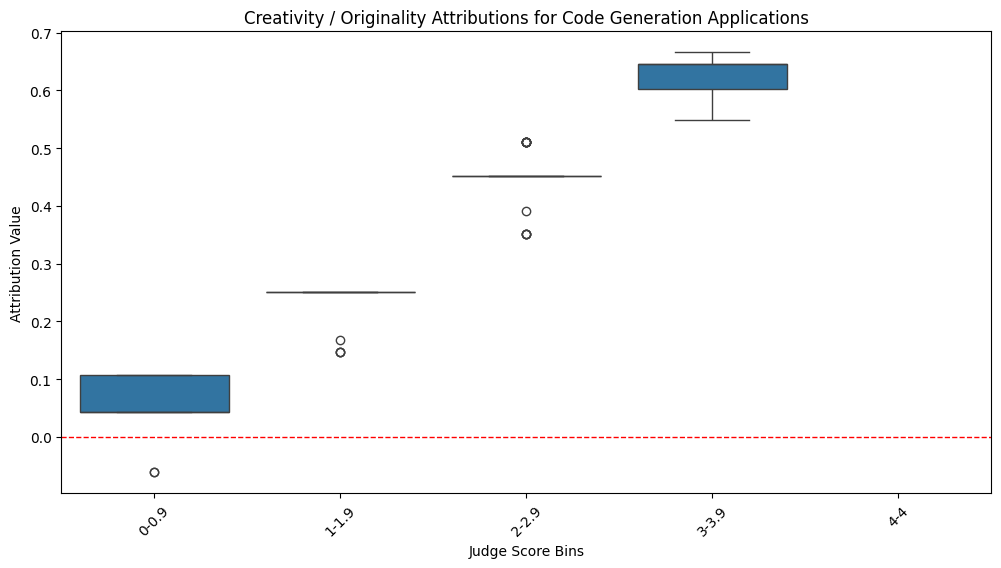

[0.9871020328668528, -0.9224459108895942, 0.9722627827315884, 0.968847534891478, 0.9714605065227832, 0.9859452278102622, 0.9145879226899961, -0.9665412118734363, 0.9694229229990727, 0.9645809362861241]


In [ ]:

spearman_correlations = breakdown_plot_by_category(data, "Code Generation", list(params['feature_importance'].keys()))
print(spearman_correlations)

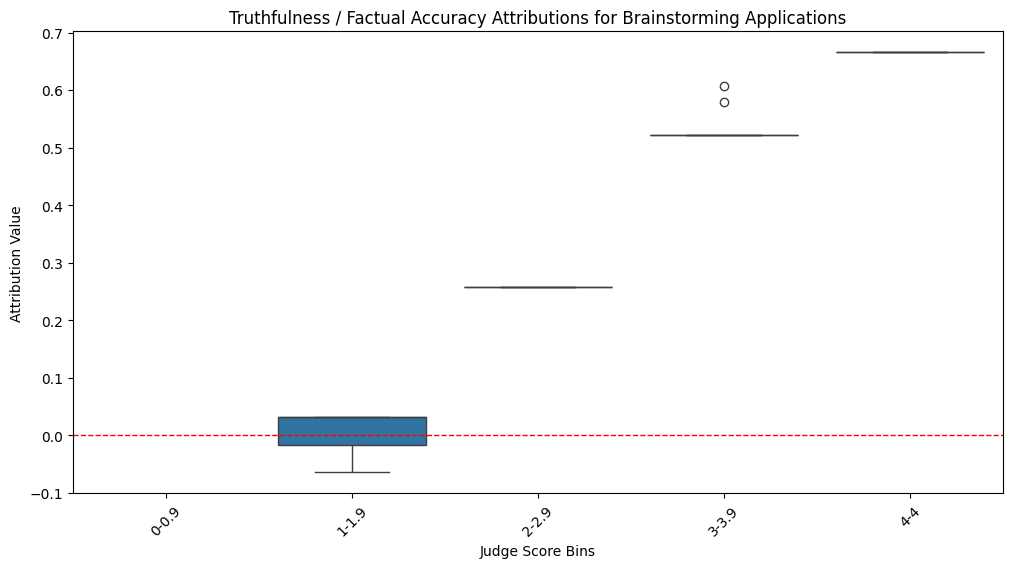

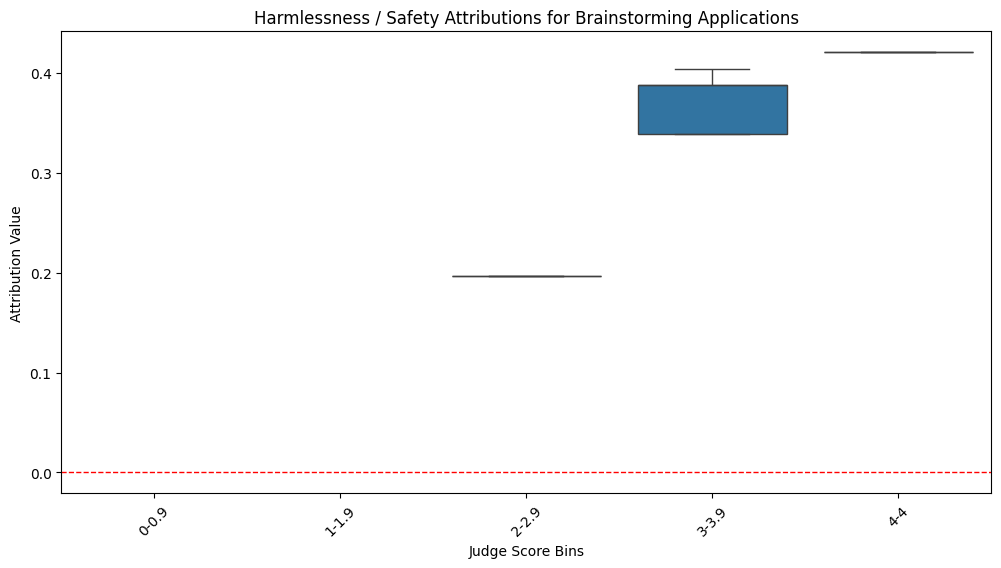

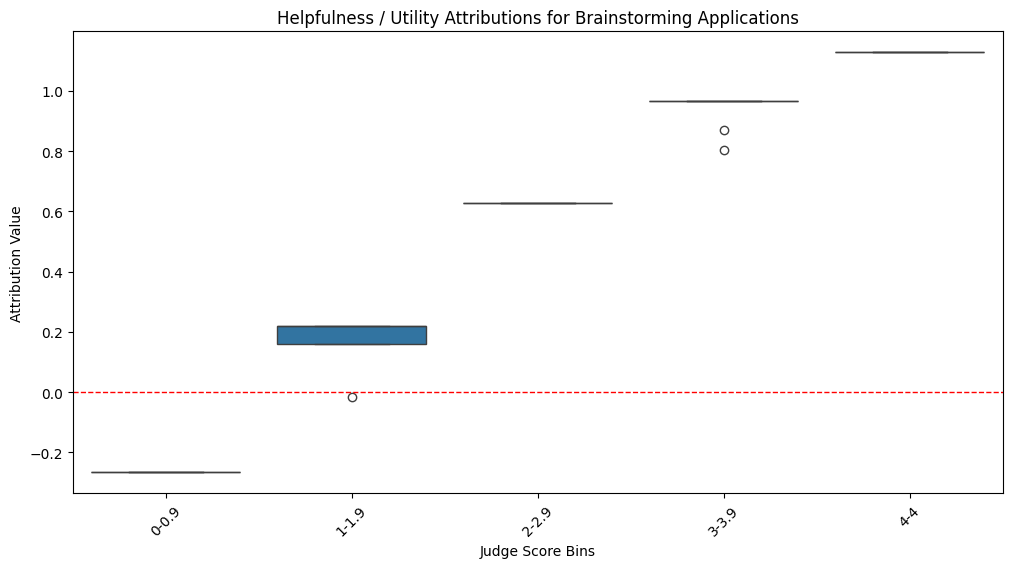

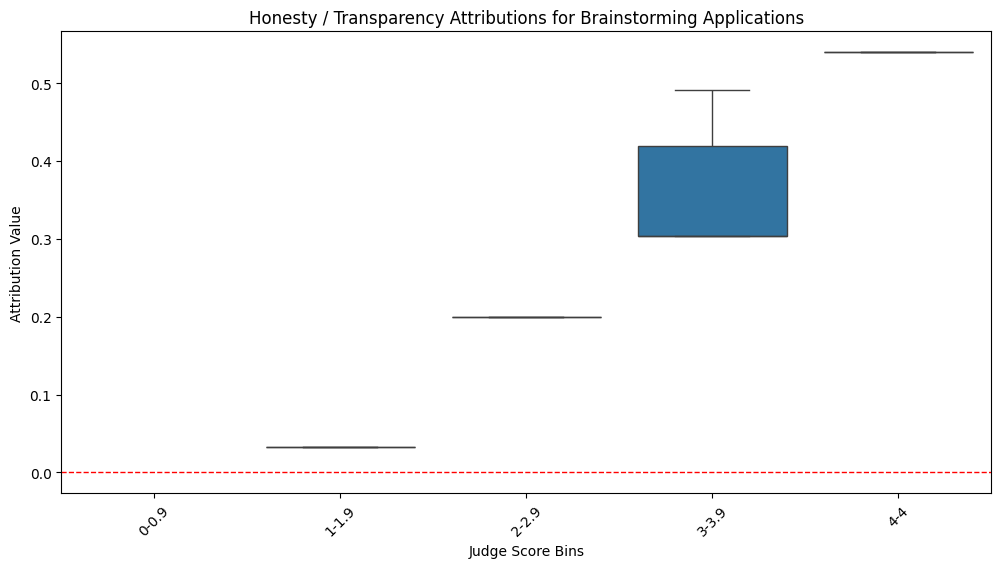

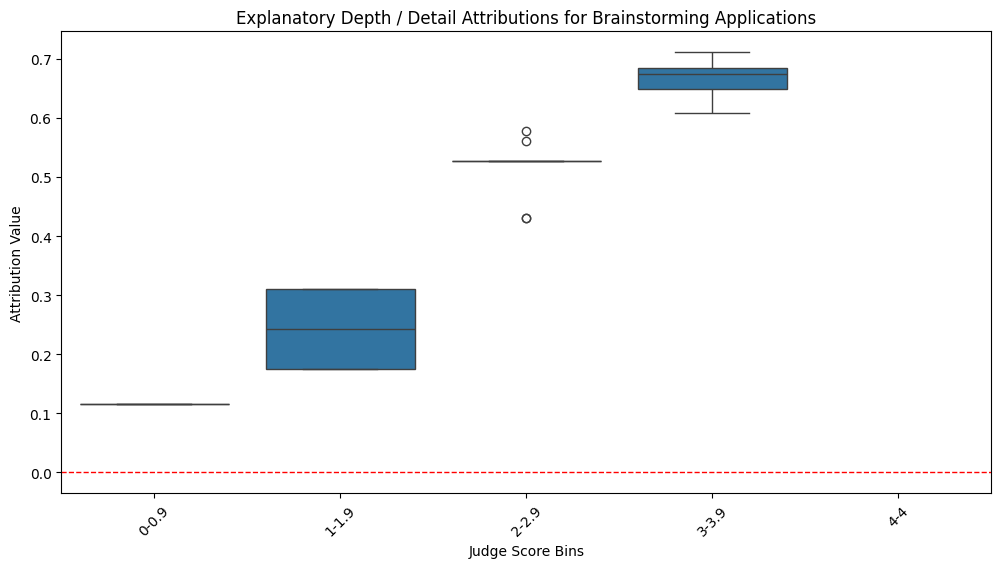

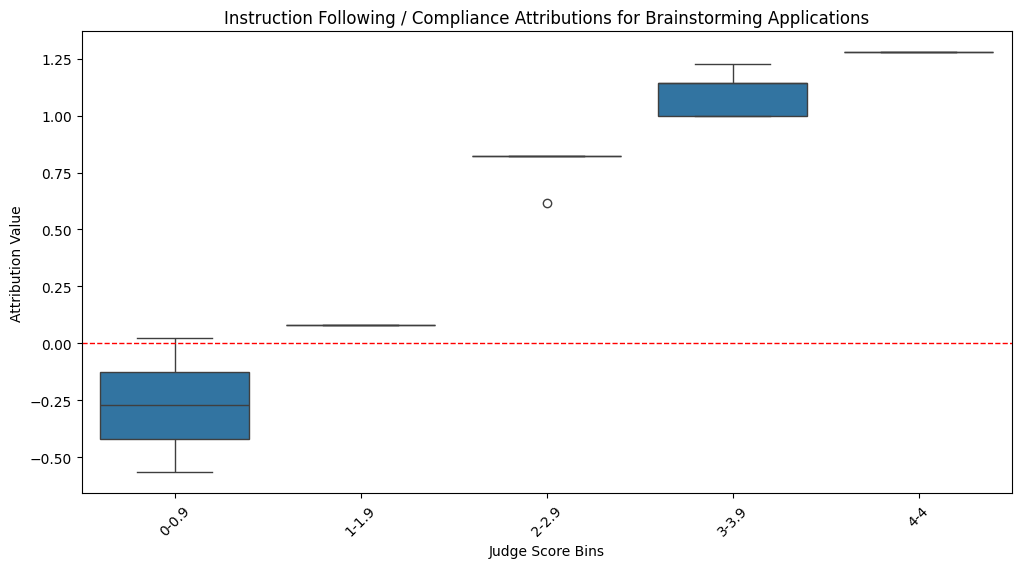

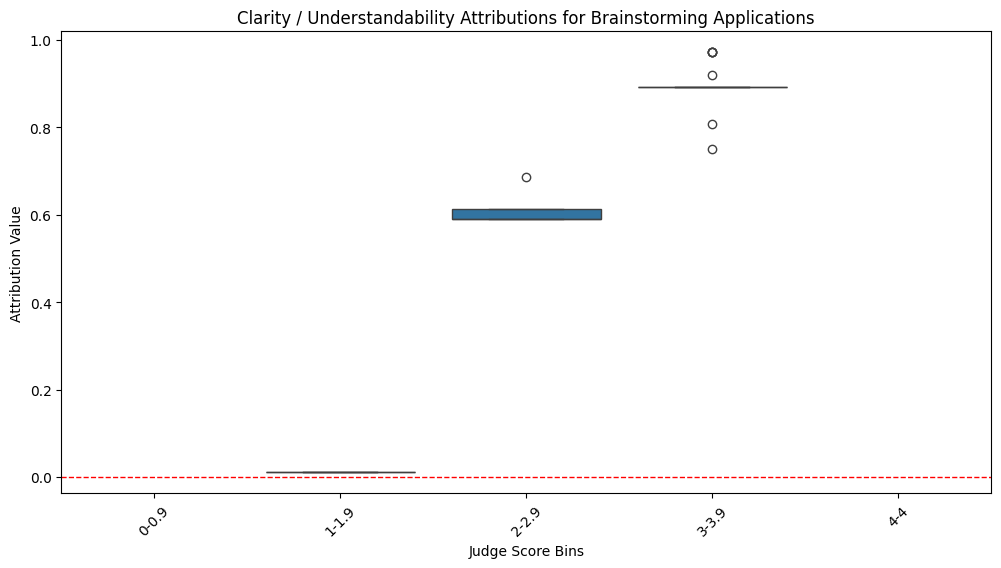

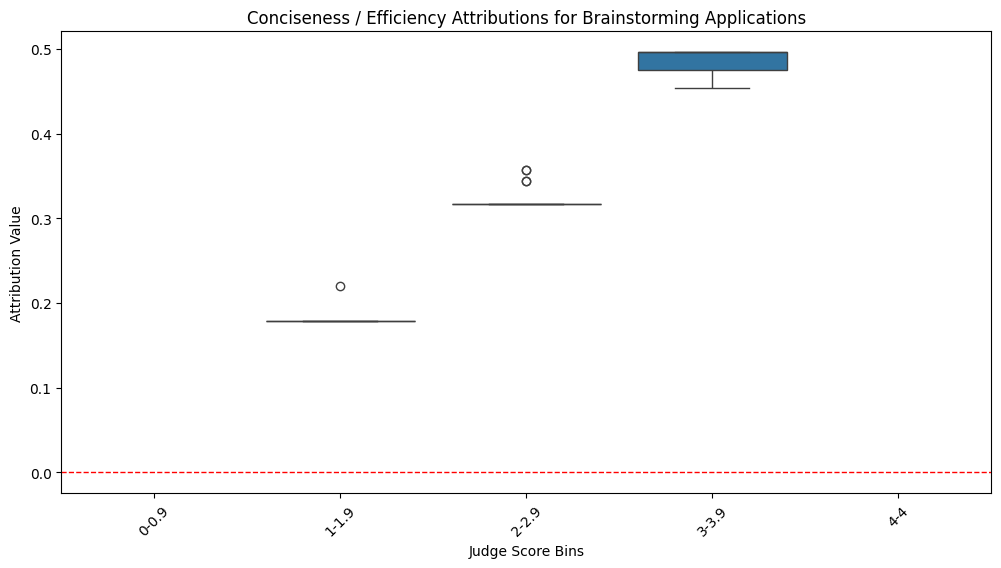

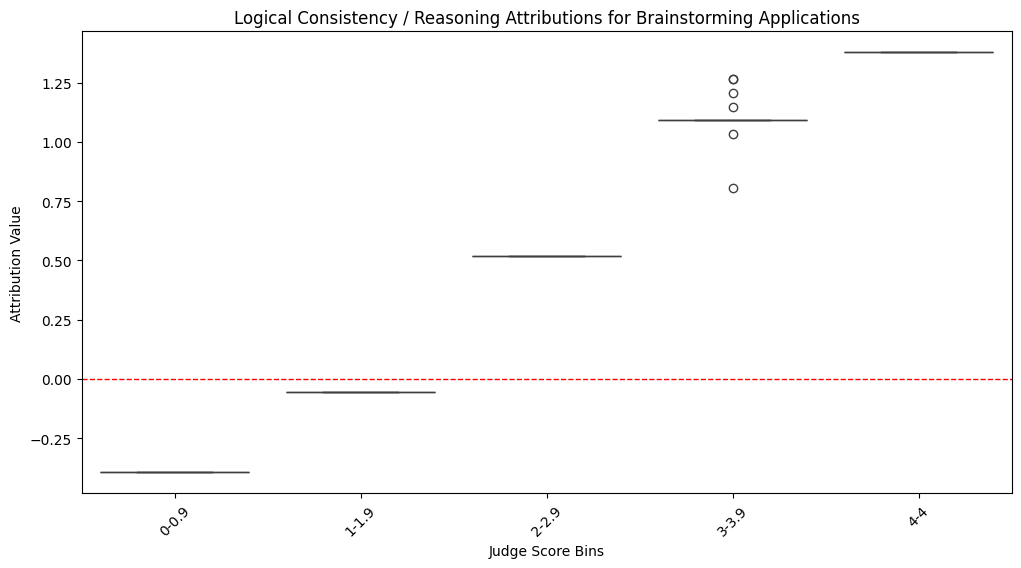

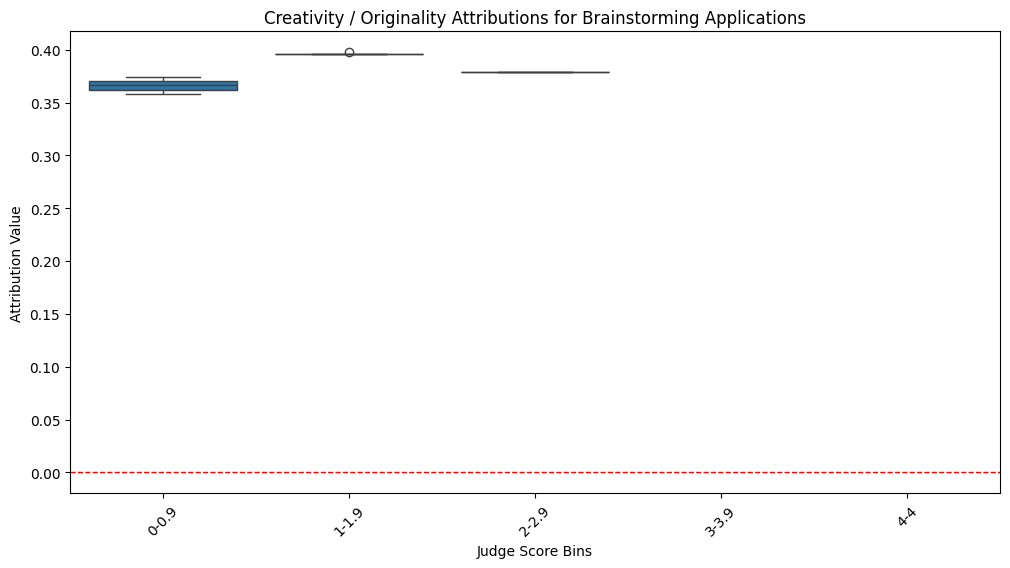

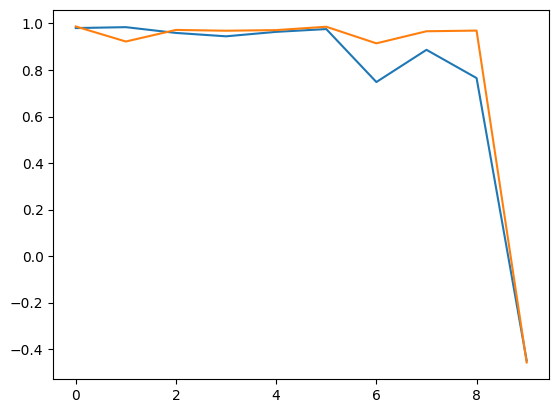

In [15]:
from matplotlib import pyplot as plt
spearman_correlations_brainstorming = breakdown_plot_by_category(data, "Brainstorming", list(params['feature_importance'].keys()))
plt.plot(spearman_correlations_brainstorming)
plt.plot(spearman_correlations)

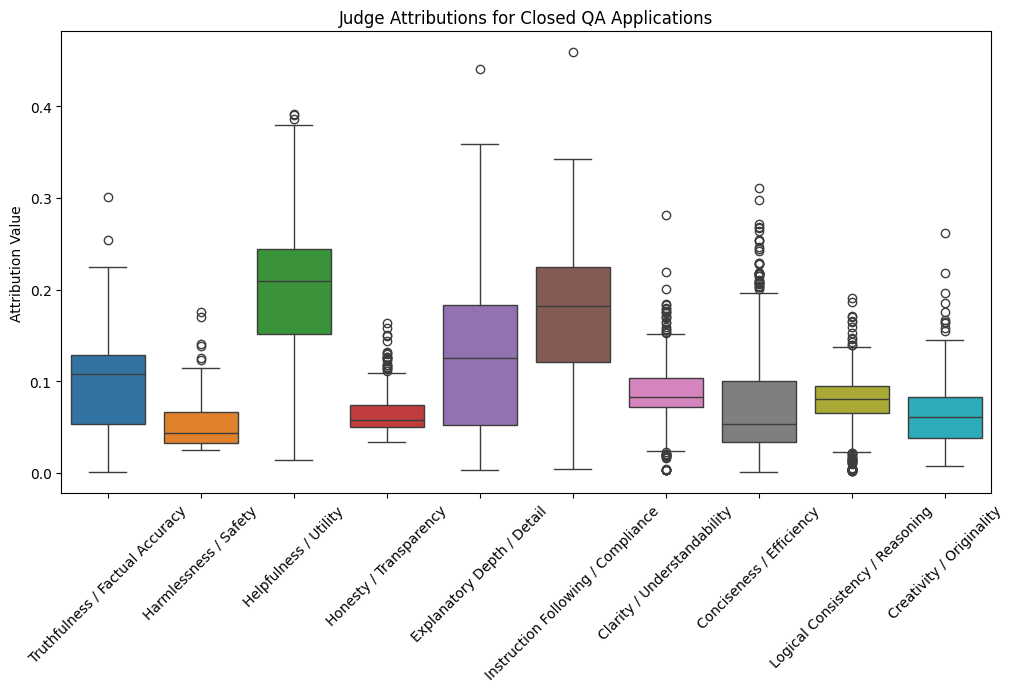

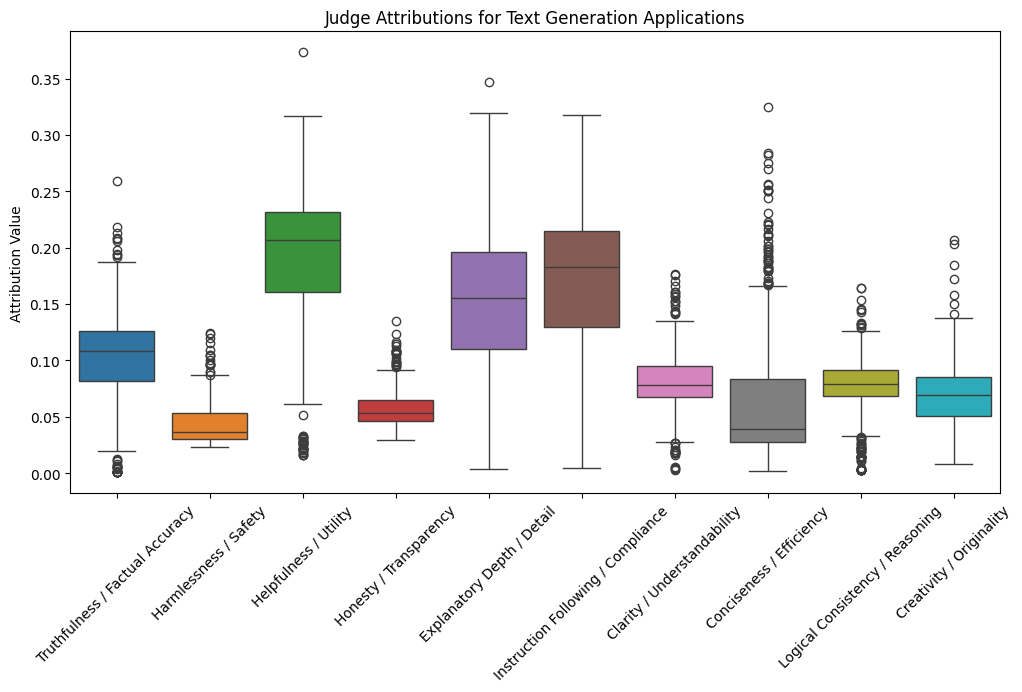

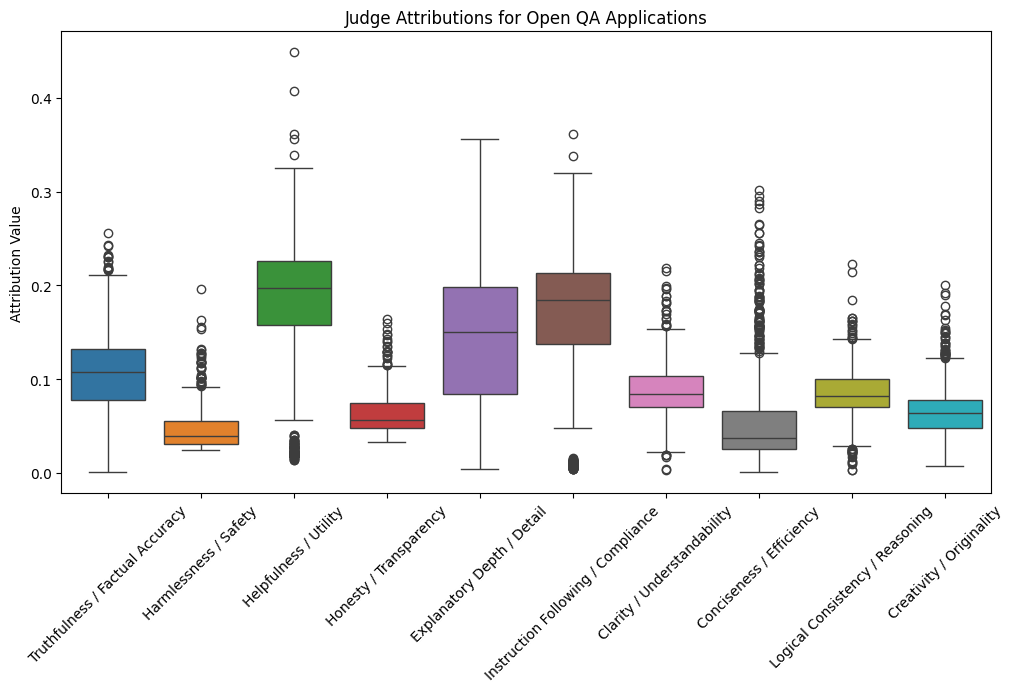

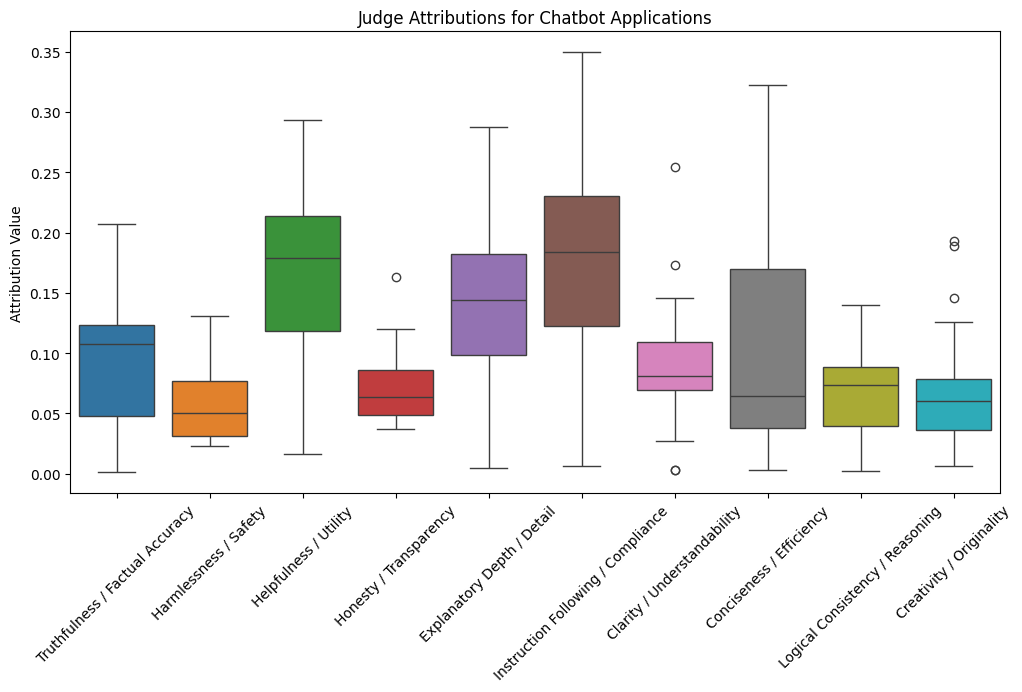

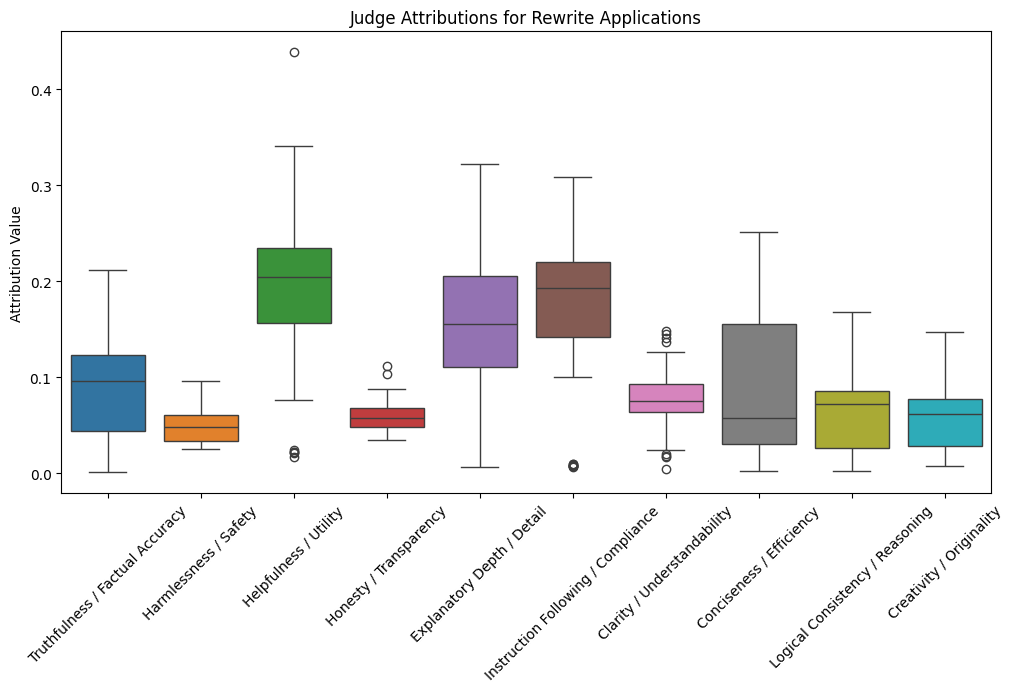

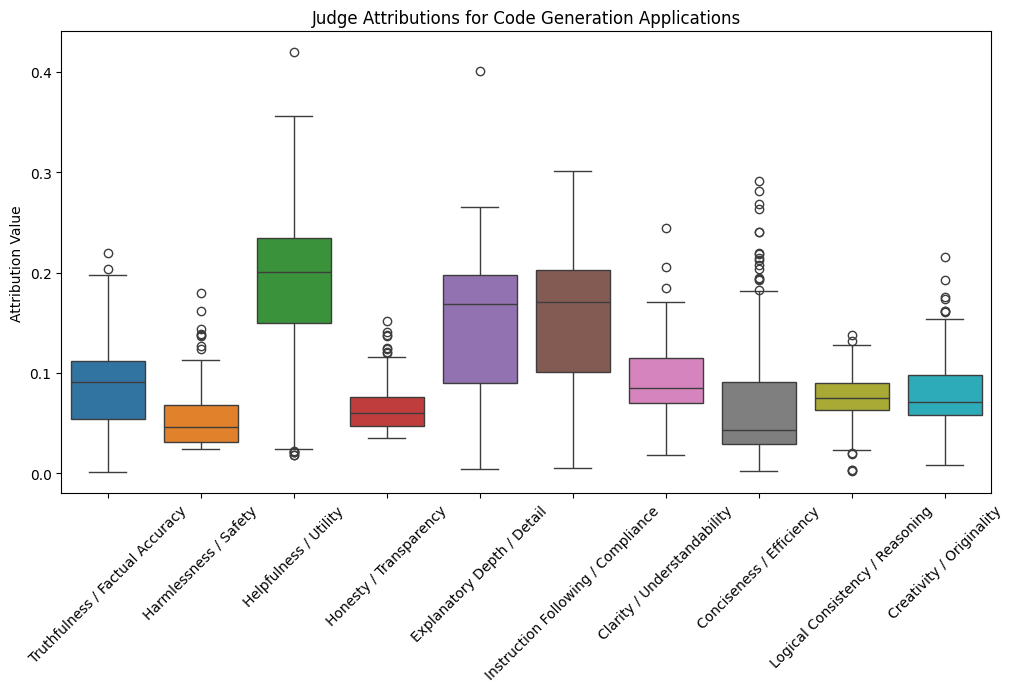

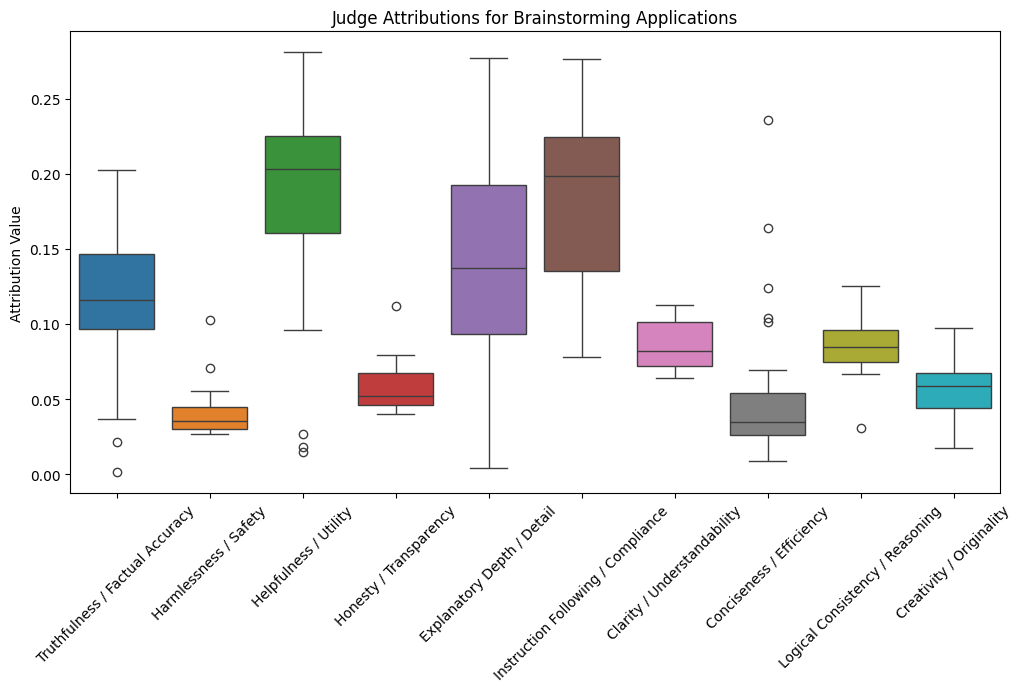

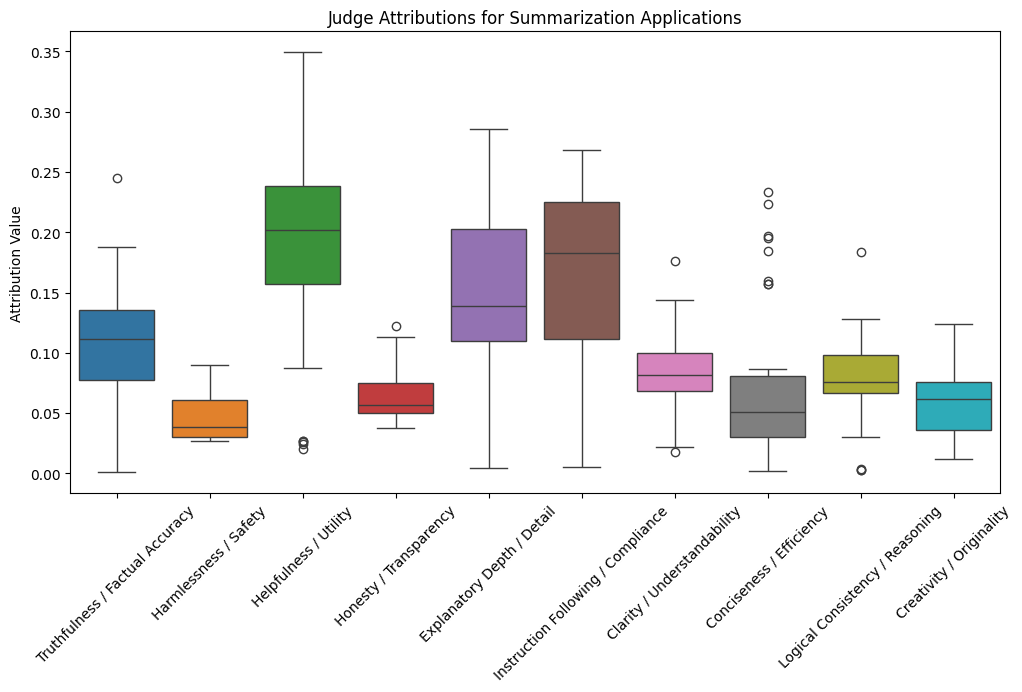

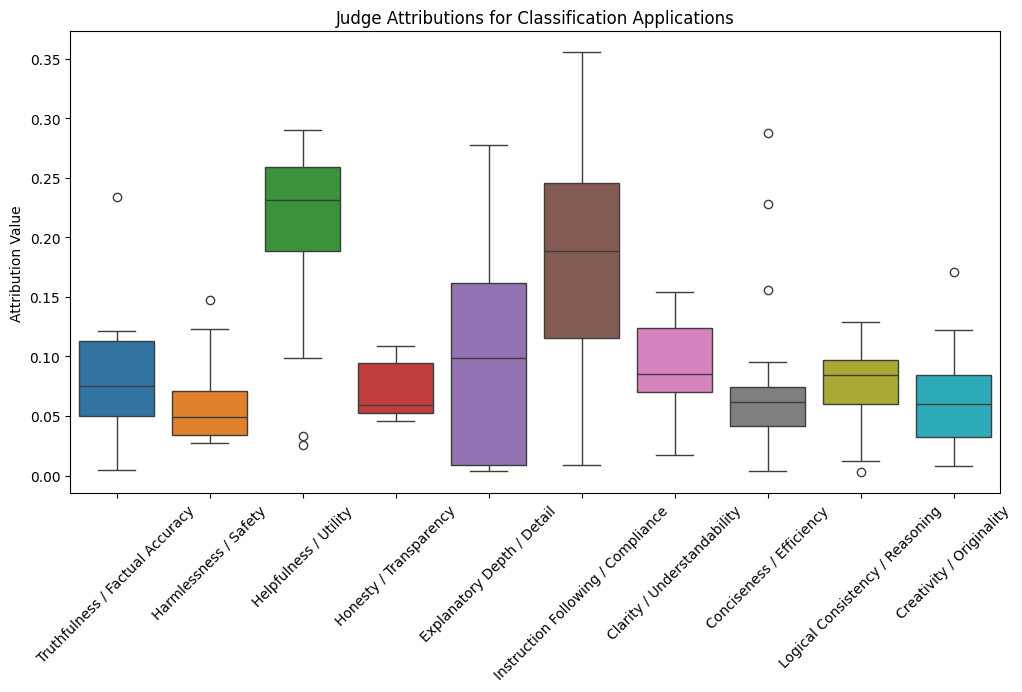

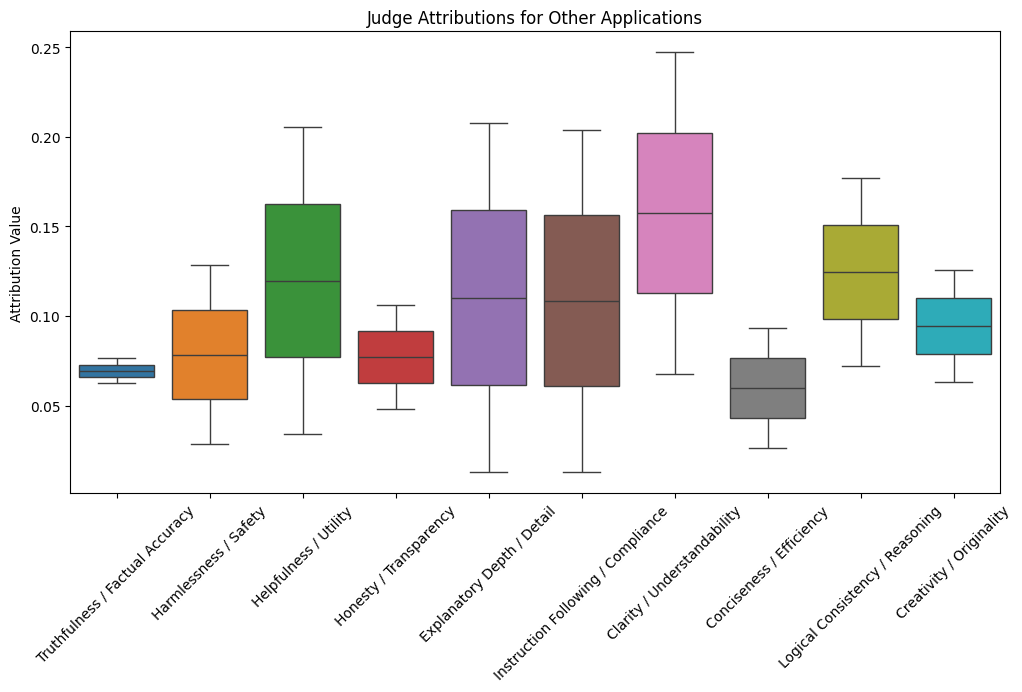

In [40]:

def box_plot_for_subset(data, subset_to_analyze, judges_names, attrib_column='attributions', output_path=None):
    # os.makedirs(output_path, exist_ok=True)
    data_subset = data[data['category'] == subset_to_analyze]
    judge_attribution_labelled = {name: [] for name in judges_names}
    for i, row in data_subset.iterrows():
        attrib  = row[attrib_column]

        for j, attr in enumerate(attrib):
            judge_name = judges_names[j]
            judge_attribution_labelled[judge_name].append(attr)
    # violin plot of attributions
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=pd.DataFrame(judge_attribution_labelled))
    plt.title(f'Judge Attributions for {subset_to_analyze} Applications')
    plt.xticks(rotation=45)
    plt.ylabel('Attribution Value')

    plt.show()
for category in data['category'].unique():
    box_plot_for_subset(data, category, list(params['feature_importance'].keys()), attrib_column='contribution')

# # 10 - Final Score
# 10 = 2 (Feature A ) + 3 (Feature B) + ...
# Feature A: 20% contribution

# 
